## **Project Setings**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from functools import partial

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif, mutual_info_regression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.base import clone
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, mean_squared_error, mean_absolute_error, r2_score,
)

import warnings
warnings.filterwarnings("ignore")

#  Estilo global 
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.0)
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

SEED = 42

# Paleta consistente 
cb = sns.color_palette("colorblind")
C_ENROLLED, C_DROPOUT = cb[0], cb[1]
C_ACCENT   = cb[3]
C_GREEN    = cb[2]
PALETTE_BIN  = {0: C_ENROLLED, 1: C_DROPOUT}
COLORS_SPLIT = {"Train": C_ENROLLED, "Val": C_DROPOUT}
CMAP_SEQ     = "YlGnBu"
CMAP_DIV     = "coolwarm"

def _booktabs(styler):
    """Apply booktabs-like borders to a pandas Styler."""
    styler.set_table_styles([
        {"selector": "thead th",
         "props": "border-bottom: 2px solid black; font-weight: bold; text-align: center;"},
        {"selector": "tbody td",
         "props": "border: none; text-align: center; color: black;"},
        {"selector": "tbody tr:last-child td",
         "props": "border-bottom: 2px solid black;"},
        {"selector": "",
         "props": "border-top: 2px solid black; border-collapse: collapse;"},
    ])
    return styler

## **Data Import**

In [30]:
# Carga del dataset
df = pd.read_csv('Data/data.csv', sep=';')

# Limpiar nombres de columnas (tabs y espacios extra)
df.columns = (
    df.columns
    .str.replace('\t', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
 )

# Renombrar columnas clave
df = df.rename(columns={
    'Target': 'Estado',
    'Curricular units 1st sem (grade)': 'first_semester_grade',
    'Curricular units 2nd sem (grade)': 'second_semester_grade'
})

# Filtrar: solo Dropout y Enrolled (excluir Graduate)
df = df[df['Estado'] != 'Graduate'].copy()

# Crear variable target de clasificación: abandona (0=Enrolled, 1=Dropout)
df['abandona'] = df['Estado'].map({'Dropout': 1, 'Enrolled': 0})

# Variable target de regresión
df['promedio_final'] = (df['first_semester_grade'] + df['second_semester_grade']) / 2

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),second_semester_grade,Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Estado,abandona,promedio_final
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.00
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.00
7,1,18,4,9254,1,1,119.0,1,37,37,...,5,0,0.0,0,15.5,2.8,-4.06,Dropout,1,0.00
9,1,1,1,9238,1,1,138.0,1,1,19,...,14,2,13.5,0,8.9,1.4,3.51,Dropout,1,12.45
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,0,0.0,0,12.7,3.7,-1.70,Dropout,1,0.00


Se excluye el estado **Graduate** de la variable target para clasificacion puesto que los graduados no son población objetivo para un sistema de alerta temprana, y mezclarlos con **Enrolled** podría confundir al modelo, puesto que el objetivo de estos datos es evitar el abandono academico de estudiantes en etapas tempranas de su carrera.

---
# **Análisis Exploratorio de Datos (EDA)**

In [31]:
EXCLUDE = ["Estado", "abandona", "promedio_final",
           "first_semester_grade", "second_semester_grade",
           "Curricular units 1st sem (approved)",
           "Curricular units 2nd sem (approved)"]

cat_nominal = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation"
]
bool_vars = [
    "Daytime/evening attendance", "Displaced",
    "Educational special needs",  "Debtor",
    "Tuition fees up to date",    "Gender",
    "Scholarship holder",         "International"
]
all_feature_cols = [c for c in df.columns if c not in EXCLUDE]
cat_nominal  = [c for c in cat_nominal  if c in df.columns]
bool_vars    = [c for c in bool_vars    if c in df.columns]
numeric_vars = [c for c in all_feature_cols
                if c not in cat_nominal and c not in bool_vars]

Se decidio excluir las columnas de `Estado, abandona, promedio_final, first_semester_grade, second_semester_grade, Curricular units 1st sem (approved), Curricular units 2nd sem (approved)`  puesto que ademas de las variables target, `first_semester_grade`, y `first_semester_grade` se derivan del promedio final del estudiante, y en el diccionario de datos se  confirma que `Curricular units 1st sem (approved)` y `Curricular units 2nd sem (approved)`son "unidades aprobadas", es decir el número de materias que el estudiante pasó. Miran exactamente lo mismo que la nota promedio pero desde otro ángulo: si aprobaste muchas materias, tu nota es alta; si aprobaste pocas o ninguna, eres candidato a Dropout. Son aproximaciones casi perfectas de ambos targets simultáneamente.

---
## **Vista General del Dataset**

  Filas       : 2215
  Columnas    : 39
  Faltantes   : 0
  Duplicados  : 0


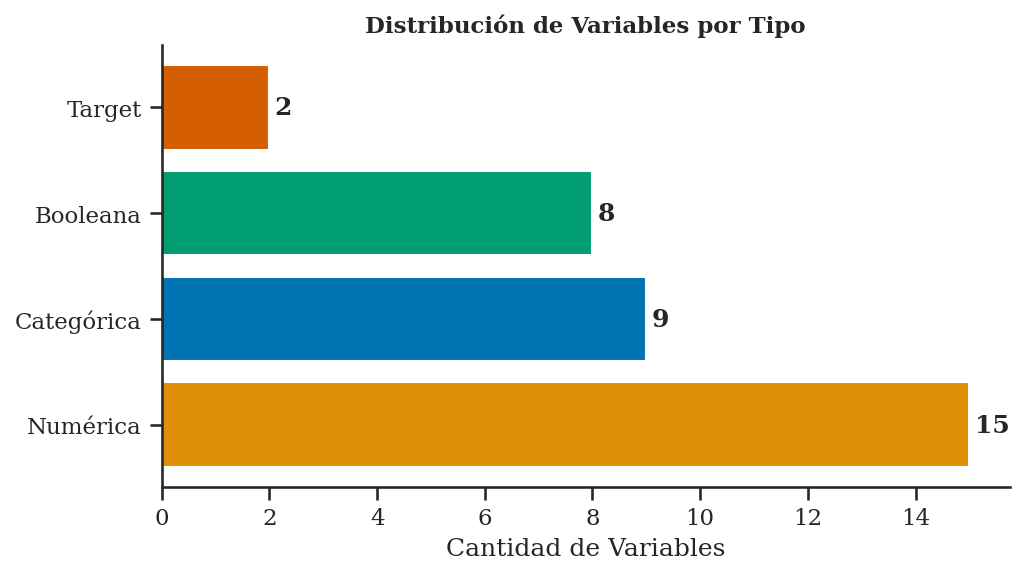

In [32]:
print("=" * 55)
print(f"  Filas       : {df.shape[0]}")
print(f"  Columnas    : {df.shape[1]}")
print(f"  Faltantes   : {df.isnull().sum().sum()}")
print(f"  Duplicados  : {df.duplicated().sum()}")
print("=" * 55)

tipo_df = pd.DataFrame({
    "Tipo": (["Categórica"] * len(cat_nominal) +
             ["Booleana"]           * len(bool_vars)   +
             ["Numérica"]           * len(numeric_vars)+
             ["Target"]             * 2),
    "Variable": cat_nominal + bool_vars + numeric_vars + ["abandona","promedio_final"]
})
conteo = tipo_df["Tipo"].value_counts().reset_index()
conteo.columns = ["Tipo", "Cantidad"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(conteo["Tipo"], conteo["Cantidad"],
        color=[C_DROPOUT, C_ENROLLED, C_GREEN, C_ACCENT], edgecolor="white")
for i, v in enumerate(conteo["Cantidad"]):
    ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
ax.set_title("Distribución de Variables por Tipo")
ax.set_xlabel("Cantidad de Variables")
sns.despine()
plt.tight_layout()
plt.show()

---
### **Variables Categóricas**

### Frecuencia de Categorías

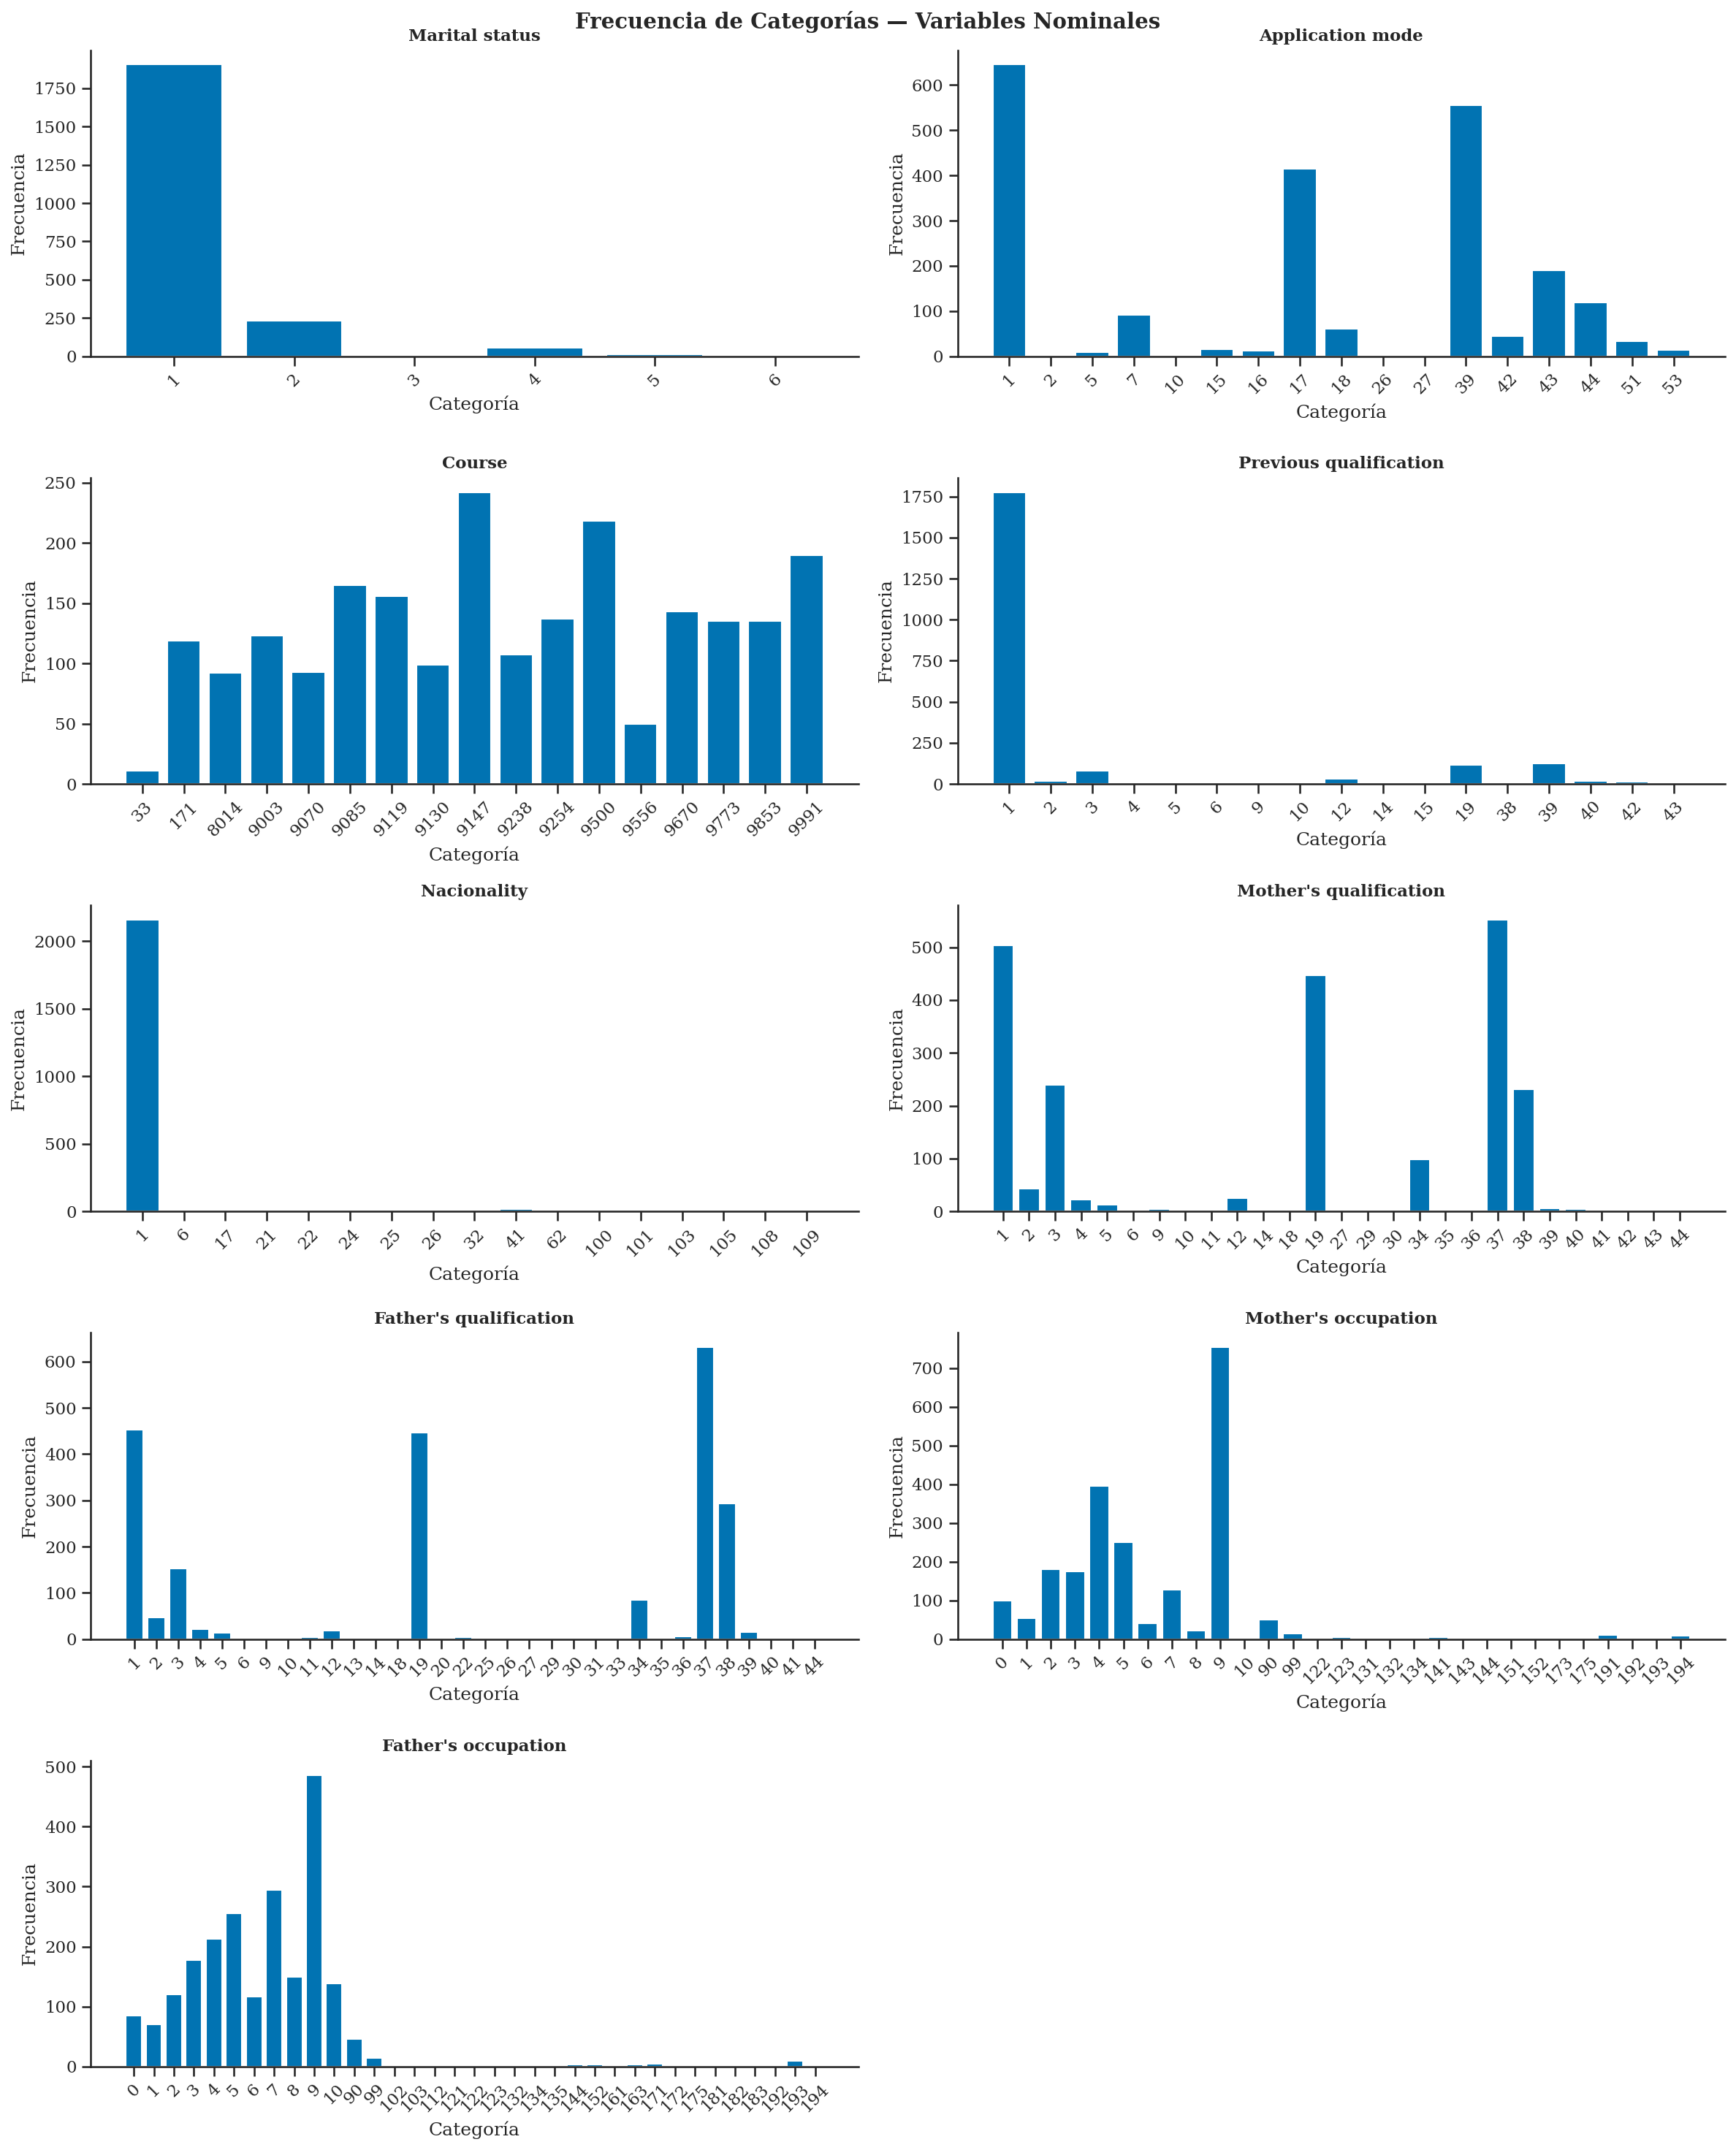

In [33]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=C_ENROLLED, edgecolor="white")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Frecuencia de Categorías — Variables Nominales",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### Tasa de Abandono por Categoría

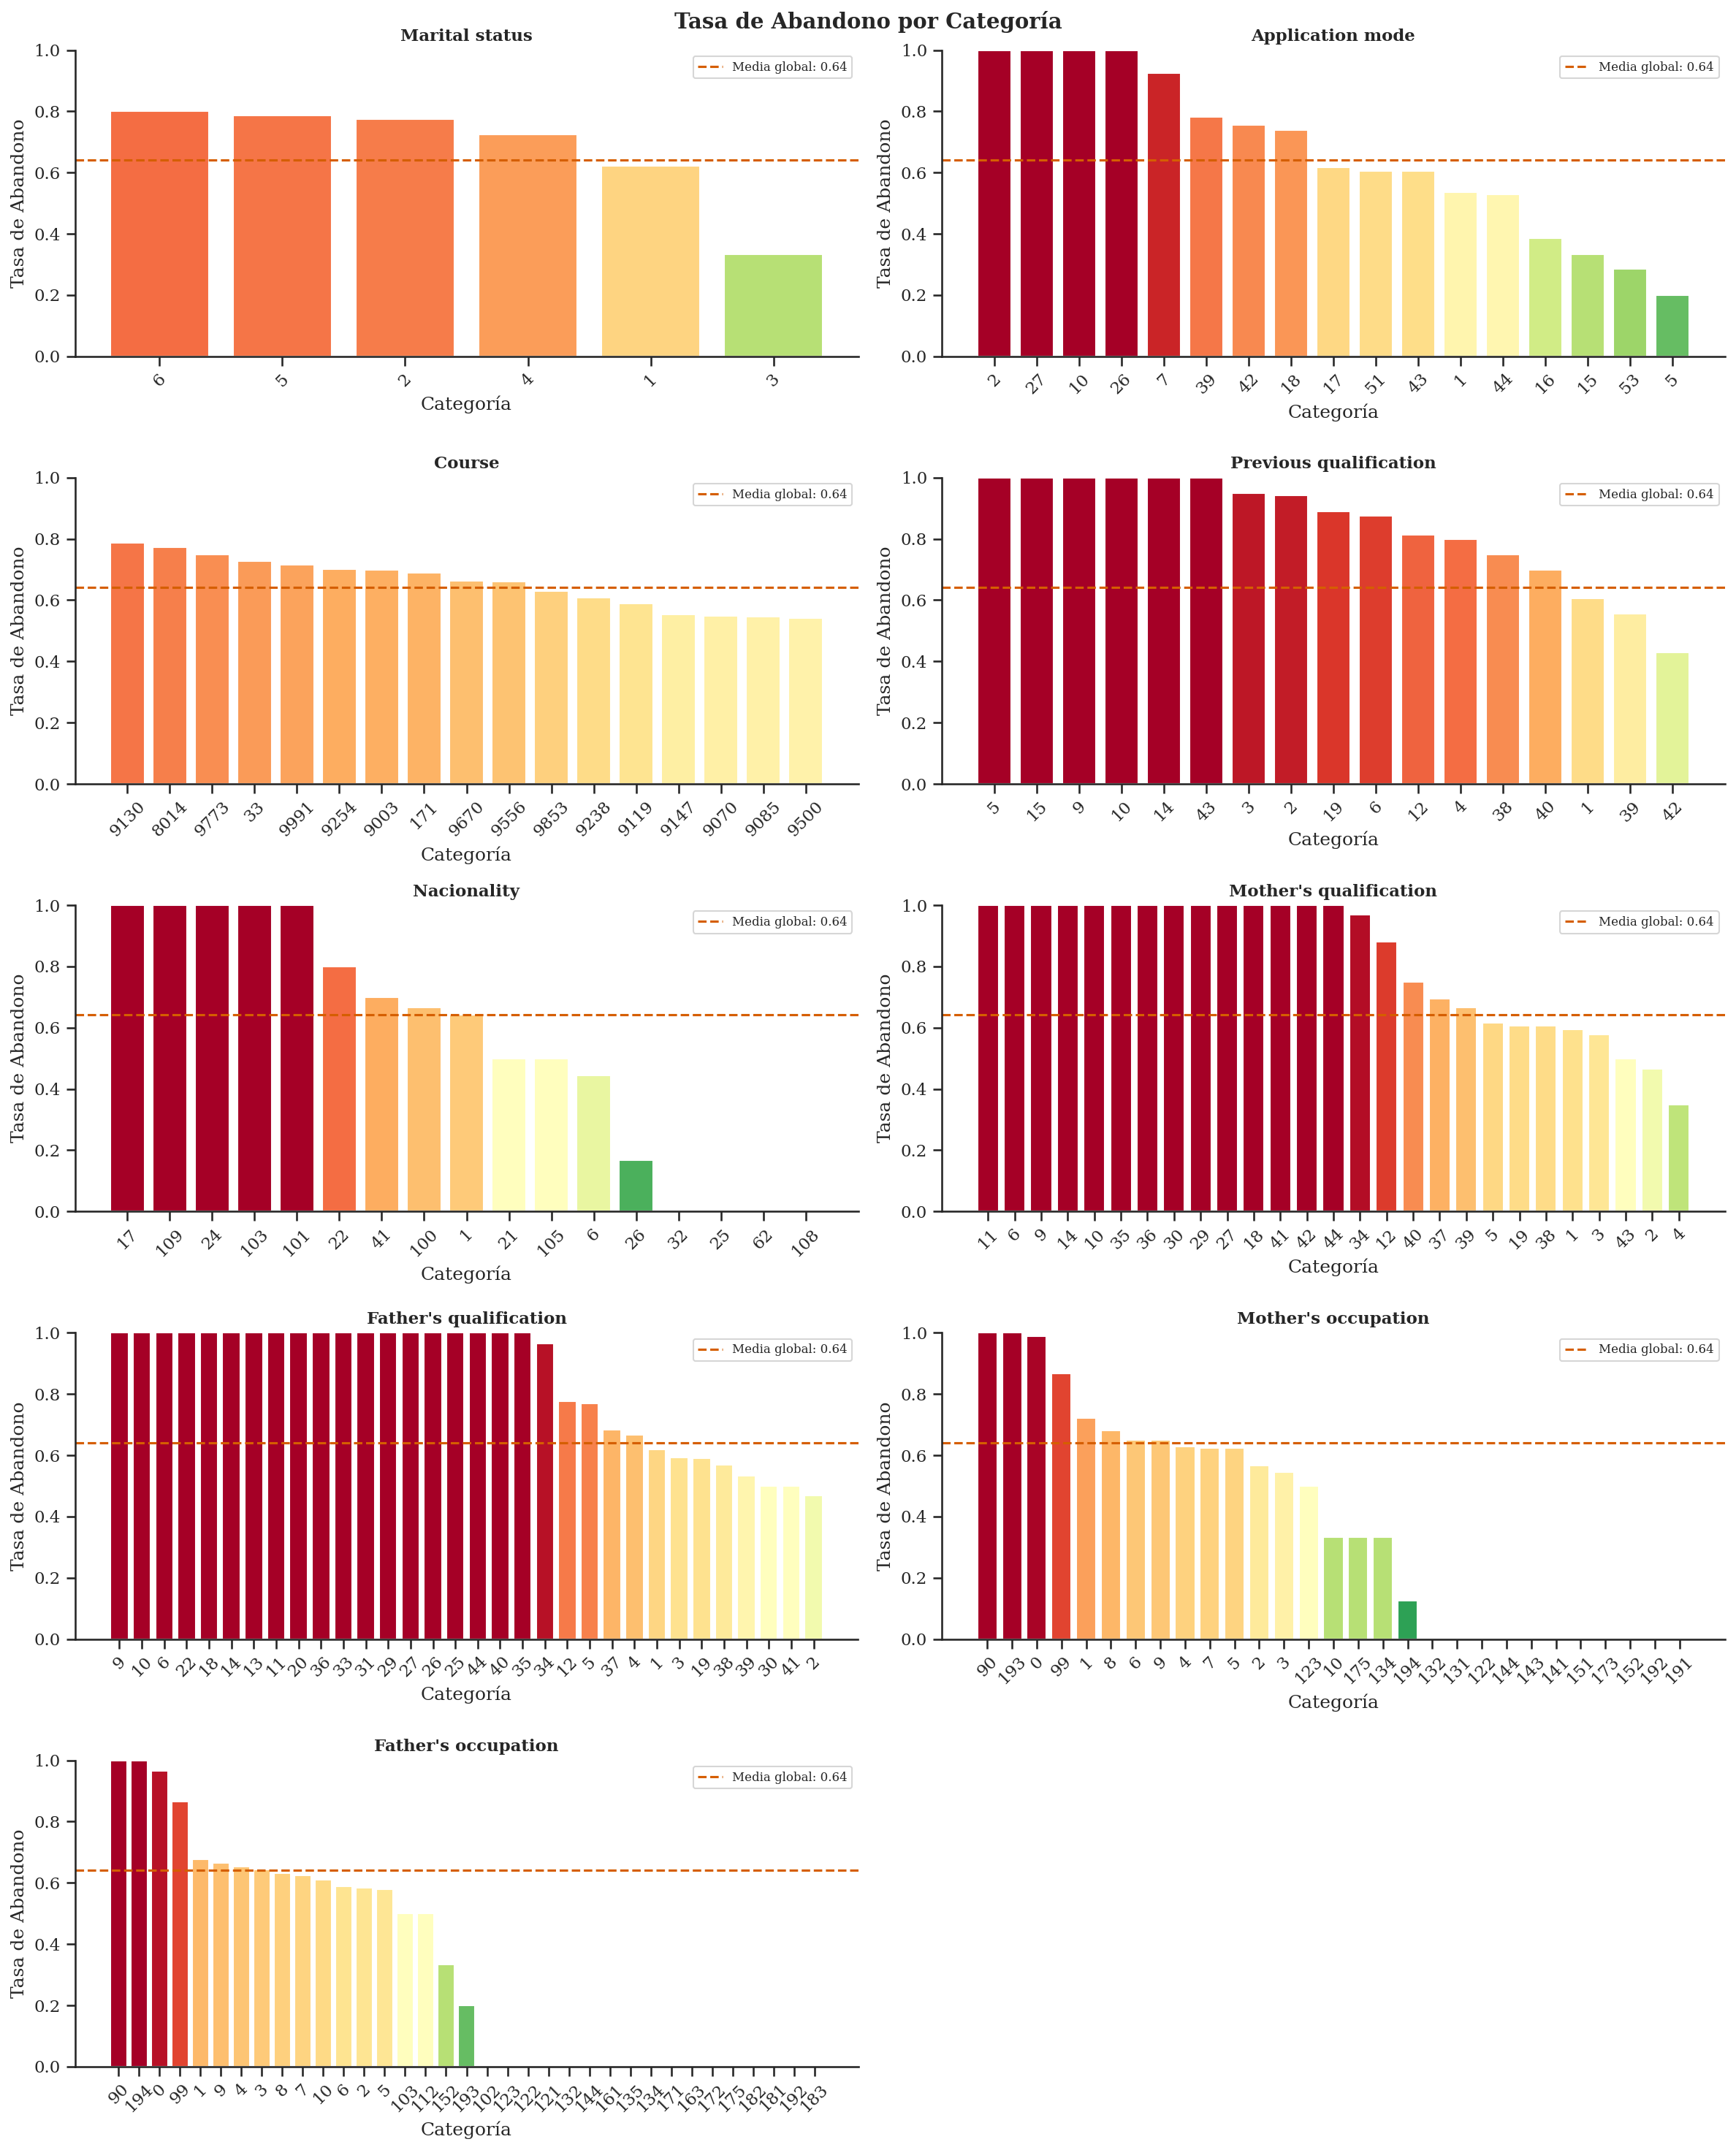

In [34]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    tasa = df.groupby(col)["abandona"].mean().sort_values(ascending=False)
    axes[i].bar(tasa.index.astype(str), tasa.values,
                color=plt.cm.RdYlGn_r(tasa.values), edgecolor="white")
    axes[i].axhline(df["abandona"].mean(), color=C_ACCENT,
                    linestyle="--", linewidth=1.5,
                    label=f'Media global: {df["abandona"].mean():.2f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Categoría",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### Distribución de `promedio_final` por Categoría

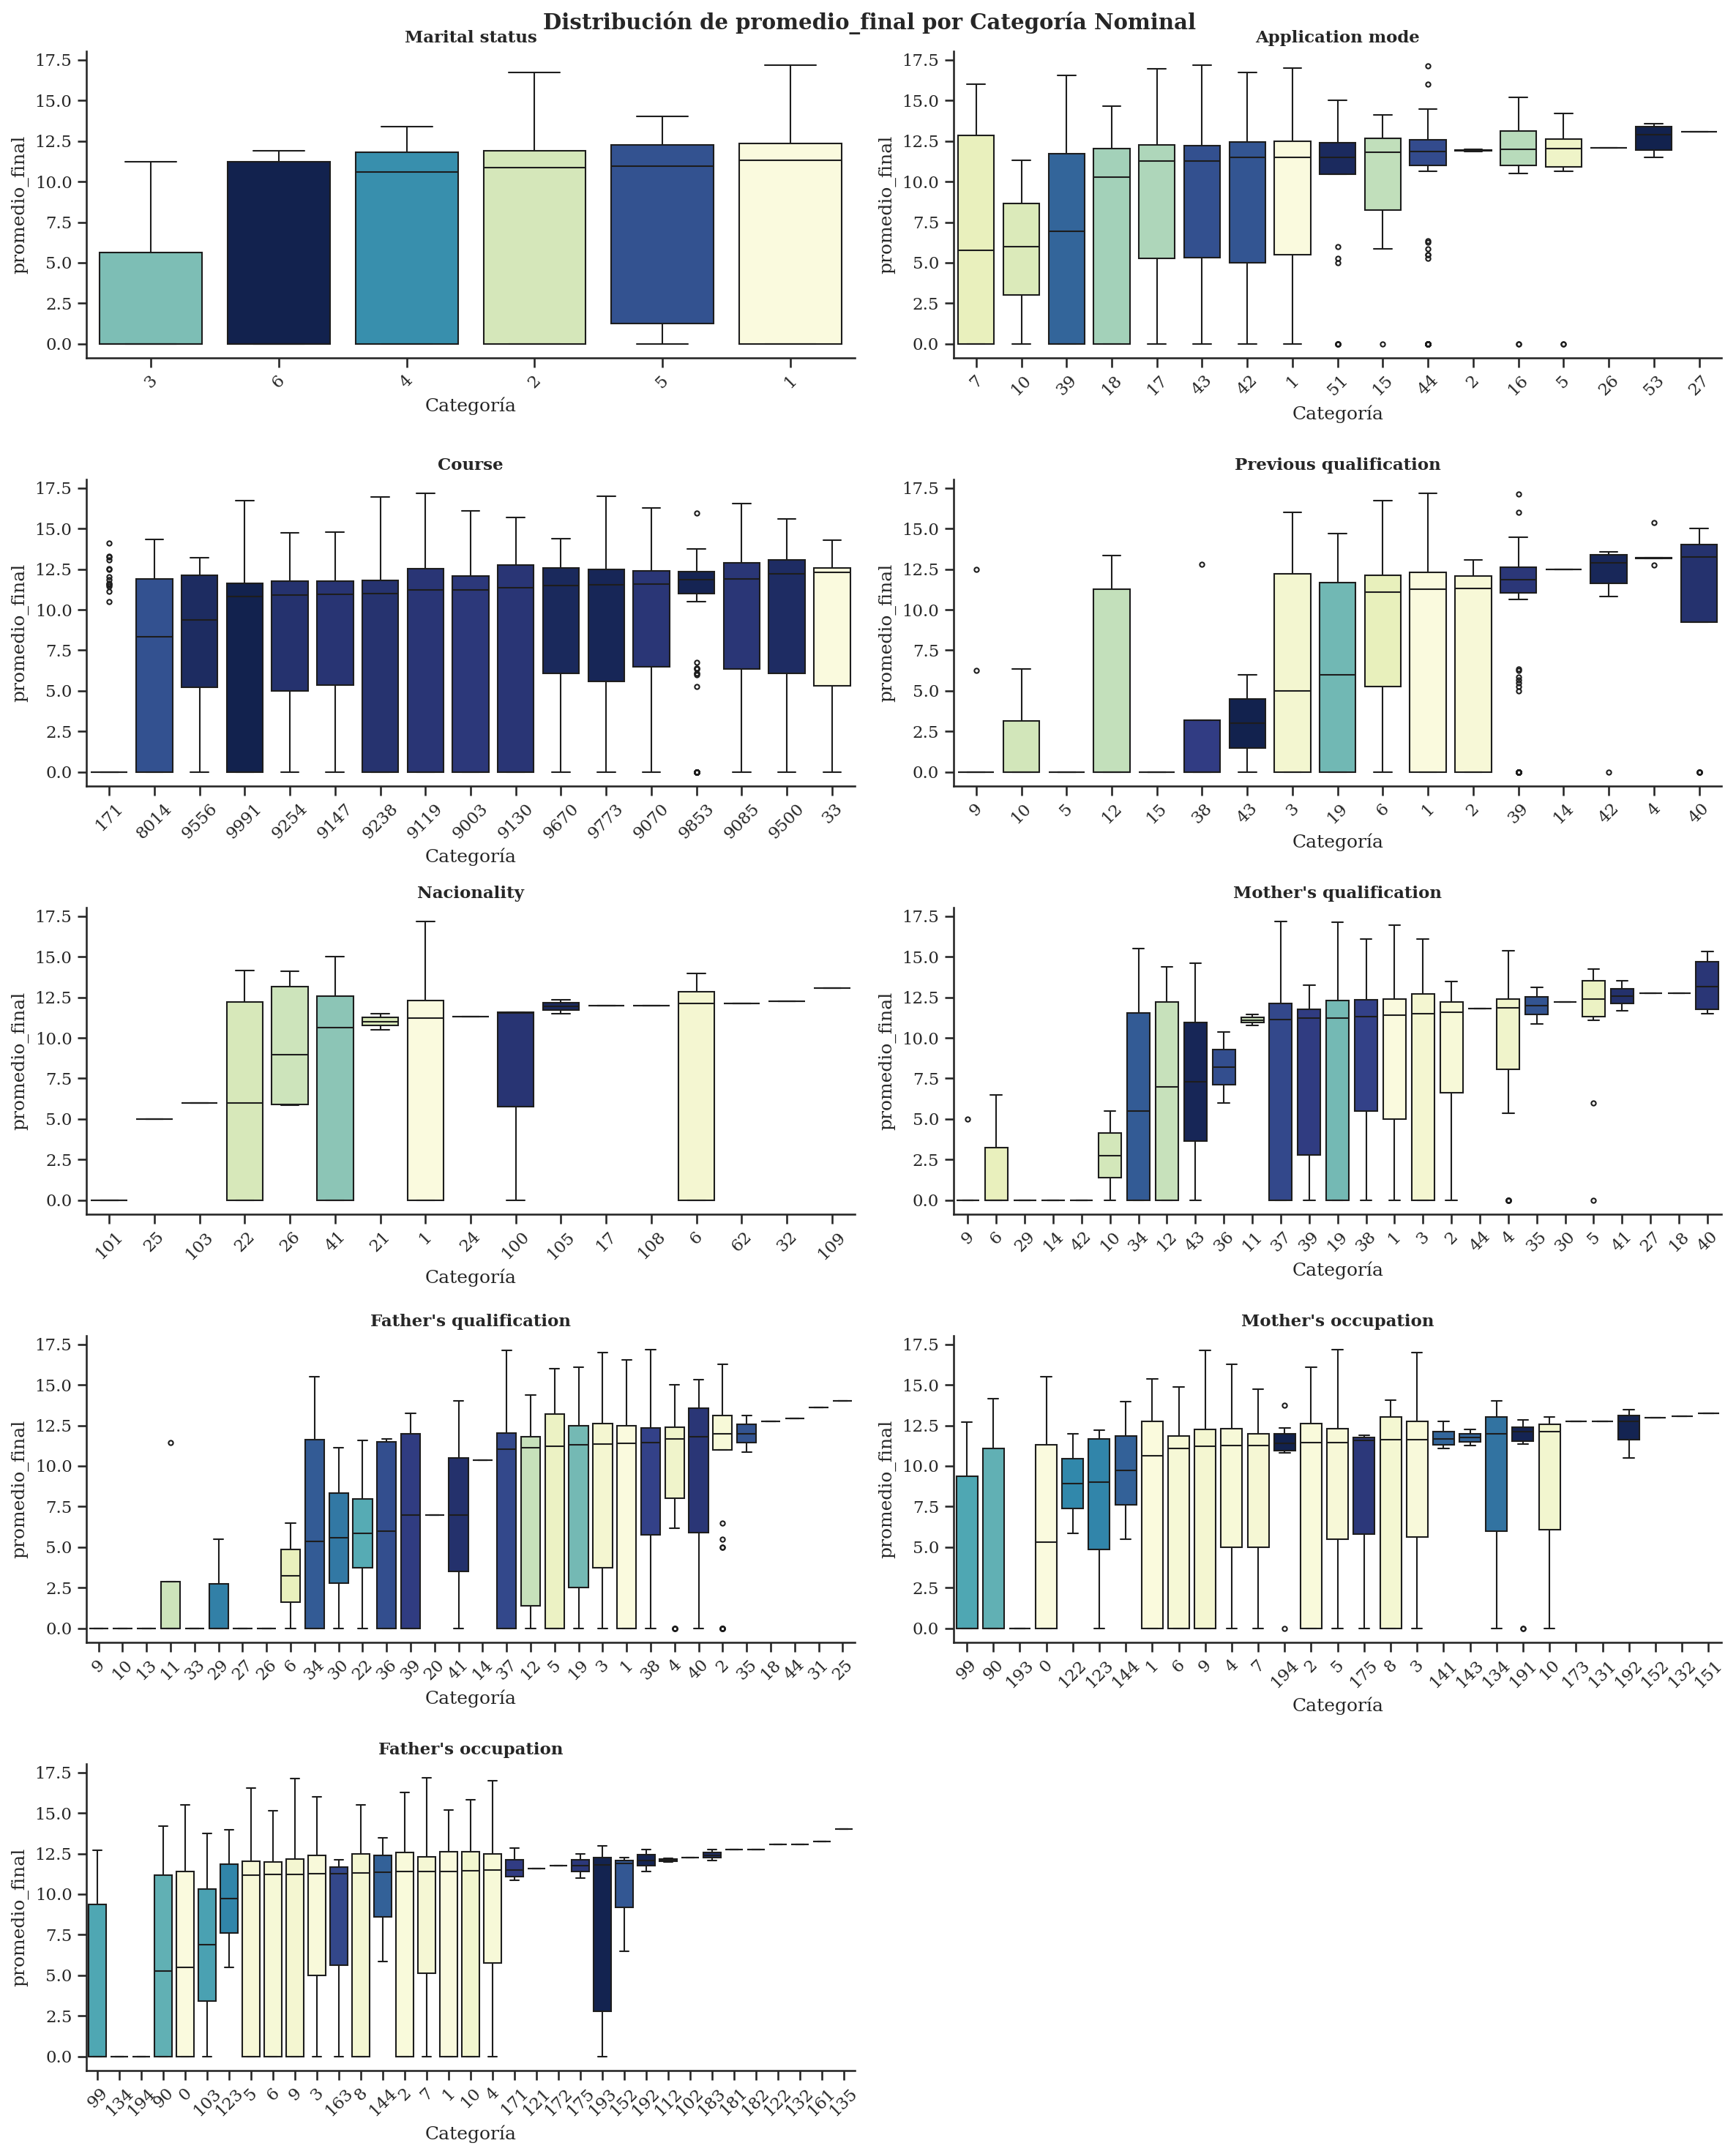

In [35]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    order = df.groupby(col)["promedio_final"].median().sort_values().index
    sns.boxplot(
        data=df, x=col, y="promedio_final",
        order=order, hue=col, legend=False, ax=axes[i],
        palette=CMAP_SEQ, flierprops={"marker":"o","markersize":3}
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("promedio_final")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de promedio_final por Categoría Nominal",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### Tabla de Contingencia con `abandona`

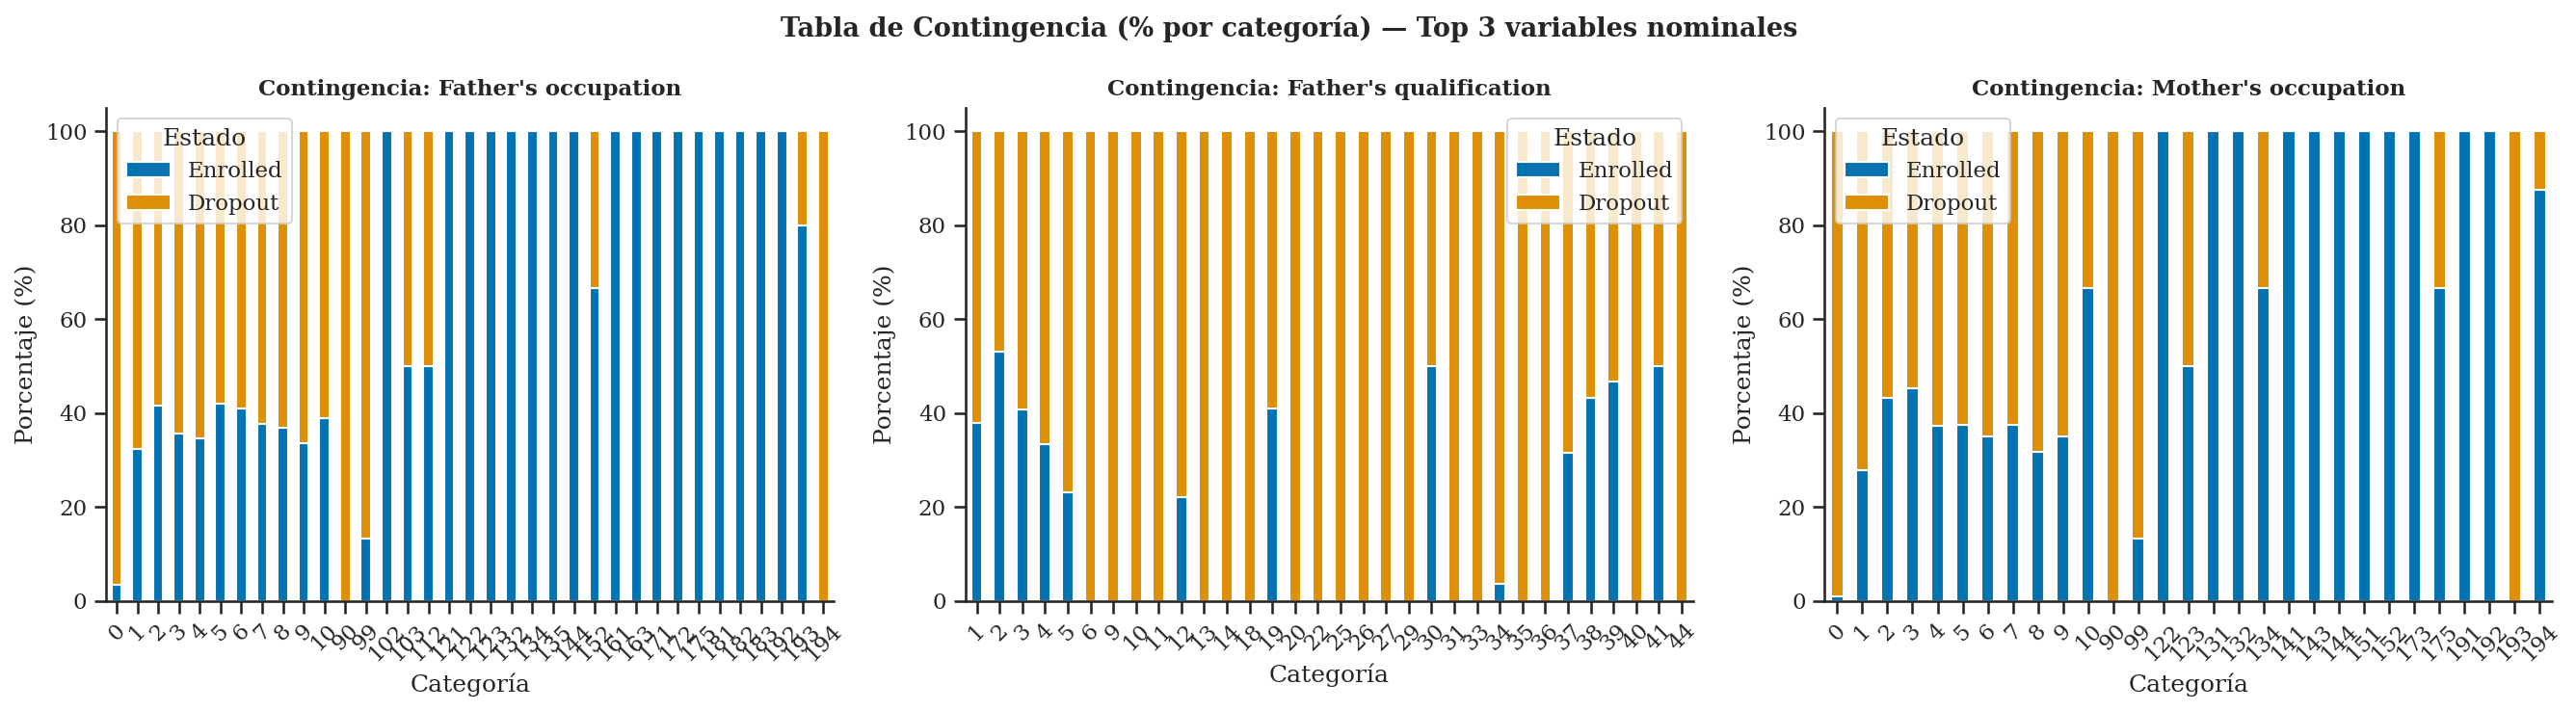


Test Chi-cuadrado (asociación con abandona):
  Variable                                chi2     p-value  Significativa
  -----------------------------------------------------------------
  Marital status                          25.8      0.0001  Sí
  Application mode                       155.7      0.0000  Sí
  Course                                  63.2      0.0000  Sí
  Previous qualification                 103.8      0.0000  Sí
  Nacionality                             18.6      0.2907  No
  Mother's qualification                 101.0      0.0000  Sí
  Father's qualification                  87.4      0.0000  Sí
  Mother's occupation                    166.2      0.0000  Sí
  Father's occupation                    140.0      0.0000  Sí


In [36]:
top_cat_vars = sorted(cat_nominal, key=lambda c: df[c].nunique(), reverse=True)[:3]

fig, axes = plt.subplots(1, len(top_cat_vars), figsize=(18, 5))

for i, col in enumerate(top_cat_vars):
    ct = pd.crosstab(df[col], df["abandona"], normalize="index") * 100
    ct.columns = ["Enrolled", "Dropout"]
    ct.plot(kind="bar", ax=axes[i], color=[C_ENROLLED, C_DROPOUT],
            edgecolor="white", stacked=True)
    axes[i].set_title(f"Contingencia: {col}", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Porcentaje (%)")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title="Estado")
    axes[i].set_ylim(0, 105)

plt.suptitle("Tabla de Contingencia (% por categoría) — Top 3 variables nominales",
             fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

print("\nTest Chi-cuadrado (asociación con abandona):")
print(f"  {"Variable":<35} {"chi2":>8}  {"p-value":>10}  Significativa")
print("  " + "-"*65)
for col in cat_nominal:
    ct = pd.crosstab(df[col], df["abandona"])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "Sí" if p < 0.05 else "No"
    print(f"  {col:<35} {chi2:>8.1f}  {p:>10.4f}  {sig}")

### Tasa de Abandono por Grupo

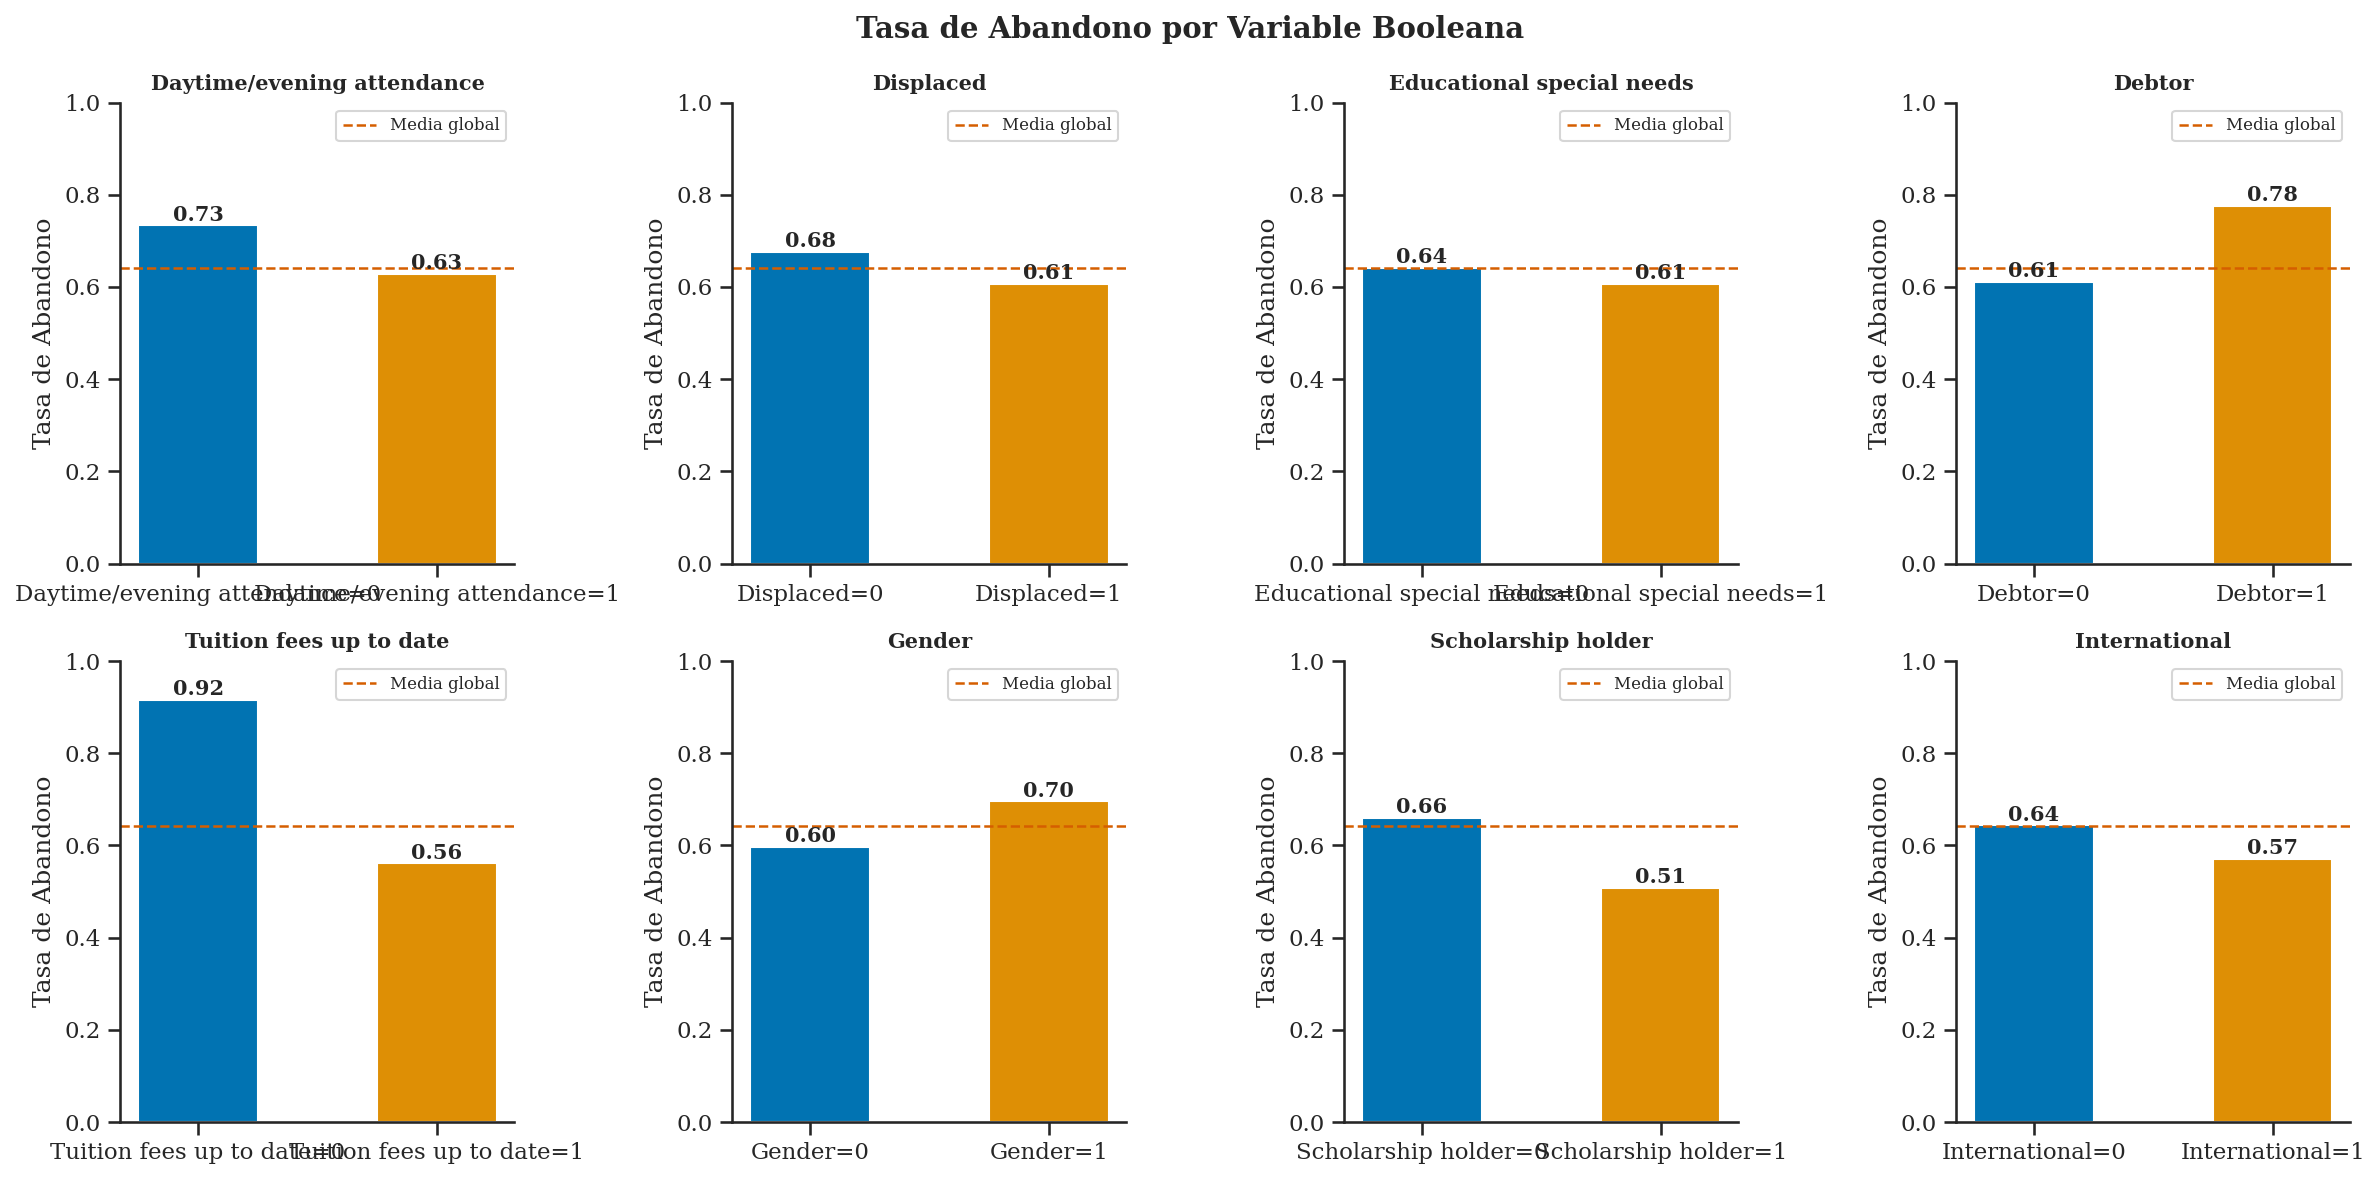

In [37]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(bool_vars):
    tasa = df.groupby(col)["abandona"].mean()
    labels = [f"{col}=0", f"{col}=1"]
    bars = axes[i].bar(labels, tasa.values,
                       color=[C_ENROLLED, C_DROPOUT], edgecolor="white", width=0.5)
    for bar, val in zip(bars, tasa.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f"{val:.2f}", ha="center", fontweight="bold", fontsize=10)
    axes[i].axhline(df["abandona"].mean(), color=C_ACCENT,
                    linestyle="--", linewidth=1.2, label="Media global")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Variable Booleana",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### Comparación de `promedio_final` entre Grupos

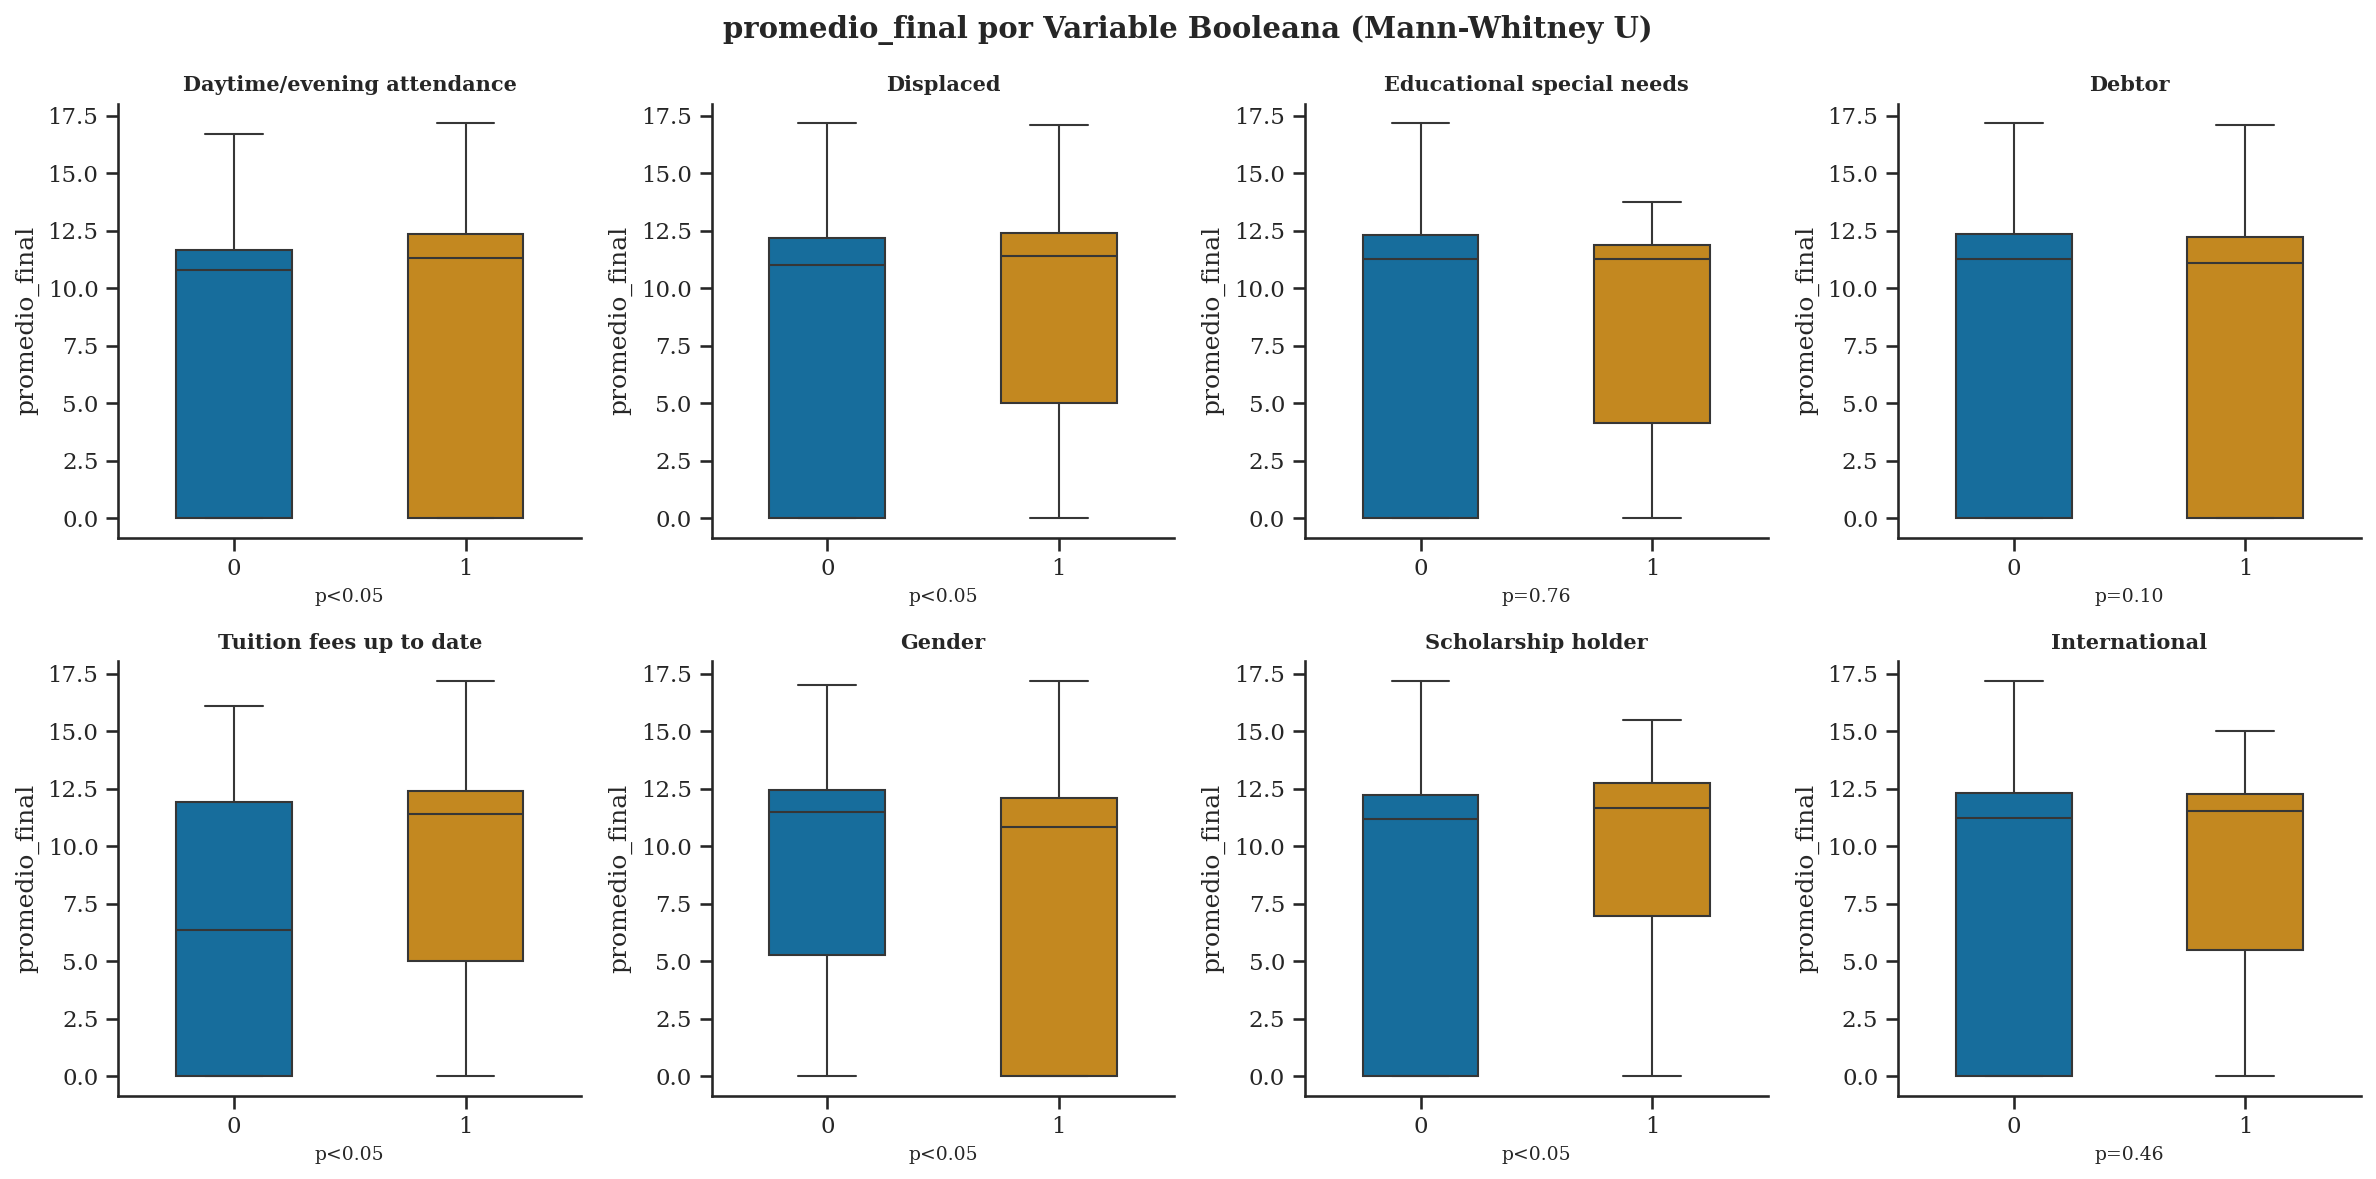

In [38]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(bool_vars):
    sns.boxplot(
        data=df, x=col, y="promedio_final", hue=col,
        palette=PALETTE_BIN, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":3}
    )
    g0 = df[df[col]==0]["promedio_final"]
    g1 = df[df[col]==1]["promedio_final"]
    if len(g0) > 0 and len(g1) > 0:
        _, p = mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "p<0.05" if p < 0.05 else f"p={p:.2f}"
        axes[i].set_xlabel(sig, fontsize=9)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("promedio_final")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0", "1"])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("promedio_final por Variable Booleana (Mann-Whitney U)",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

### Estadísticas Descriptivas por Clase

In [39]:
desc_dropout  = df[df["abandona"]==1][numeric_vars].describe().T
desc_enrolled = df[df["abandona"]==0][numeric_vars].describe().T

desc_combined = desc_dropout[["mean","std","50%"]].copy()
desc_combined.columns = ["mean_dropout","std_dropout","median_dropout"]
desc_combined["mean_enrolled"]   = desc_enrolled["mean"]
desc_combined["std_enrolled"]    = desc_enrolled["std"]
desc_combined["median_enrolled"] = desc_enrolled["50%"]
desc_combined["diff_means"]      = (desc_combined["mean_dropout"]
                                    - desc_combined["mean_enrolled"]).round(3)

print("Estadísticas descriptivas por clase (Dropout vs Enrolled):")
display(_booktabs(
    desc_combined.round(3).style
    .background_gradient(cmap=CMAP_DIV, subset=["diff_means"], vmin=-5, vmax=5)
))

Estadísticas descriptivas por clase (Dropout vs Enrolled):


,mean_dropout,std_dropout,median_dropout,mean_enrolled,std_enrolled,median_enrolled,diff_means
Application order,1.593000,1.216000,1.000000,1.626000,1.214000,1.000000,-0.033000
Previous qualification (grade),131.114000,12.873000,133.100000,131.208000,12.872000,130.000000,-0.094000
Admission grade,124.961000,15.125000,123.600000,125.534000,13.793000,124.100000,-0.573000
Age at enrollment,26.069000,8.704000,23.000000,22.369000,6.303000,20.000000,3.700000
Curricular units 1st sem (credited),0.609000,2.105000,0.000000,0.508000,1.716000,0.000000,0.102000
Curricular units 1st sem (enrolled),5.821000,2.326000,6.000000,5.965000,1.988000,6.000000,-0.143000
Curricular units 1st sem (evaluations),7.752000,4.922000,8.000000,9.341000,3.463000,9.000000,-1.590000
Curricular units 1st sem (without evaluations),0.192000,0.795000,0.000000,0.178000,0.741000,0.000000,0.015000
Curricular units 2nd sem (credited),0.450000,1.680000,0.000000,0.359000,1.329000,0.000000,0.091000
Curricular units 2nd sem (enrolled),5.780000,2.108000,6.000000,5.938000,1.831000,6.000000,-0.158000


### Histogramas por Clase (Dropout vs Enrolled)

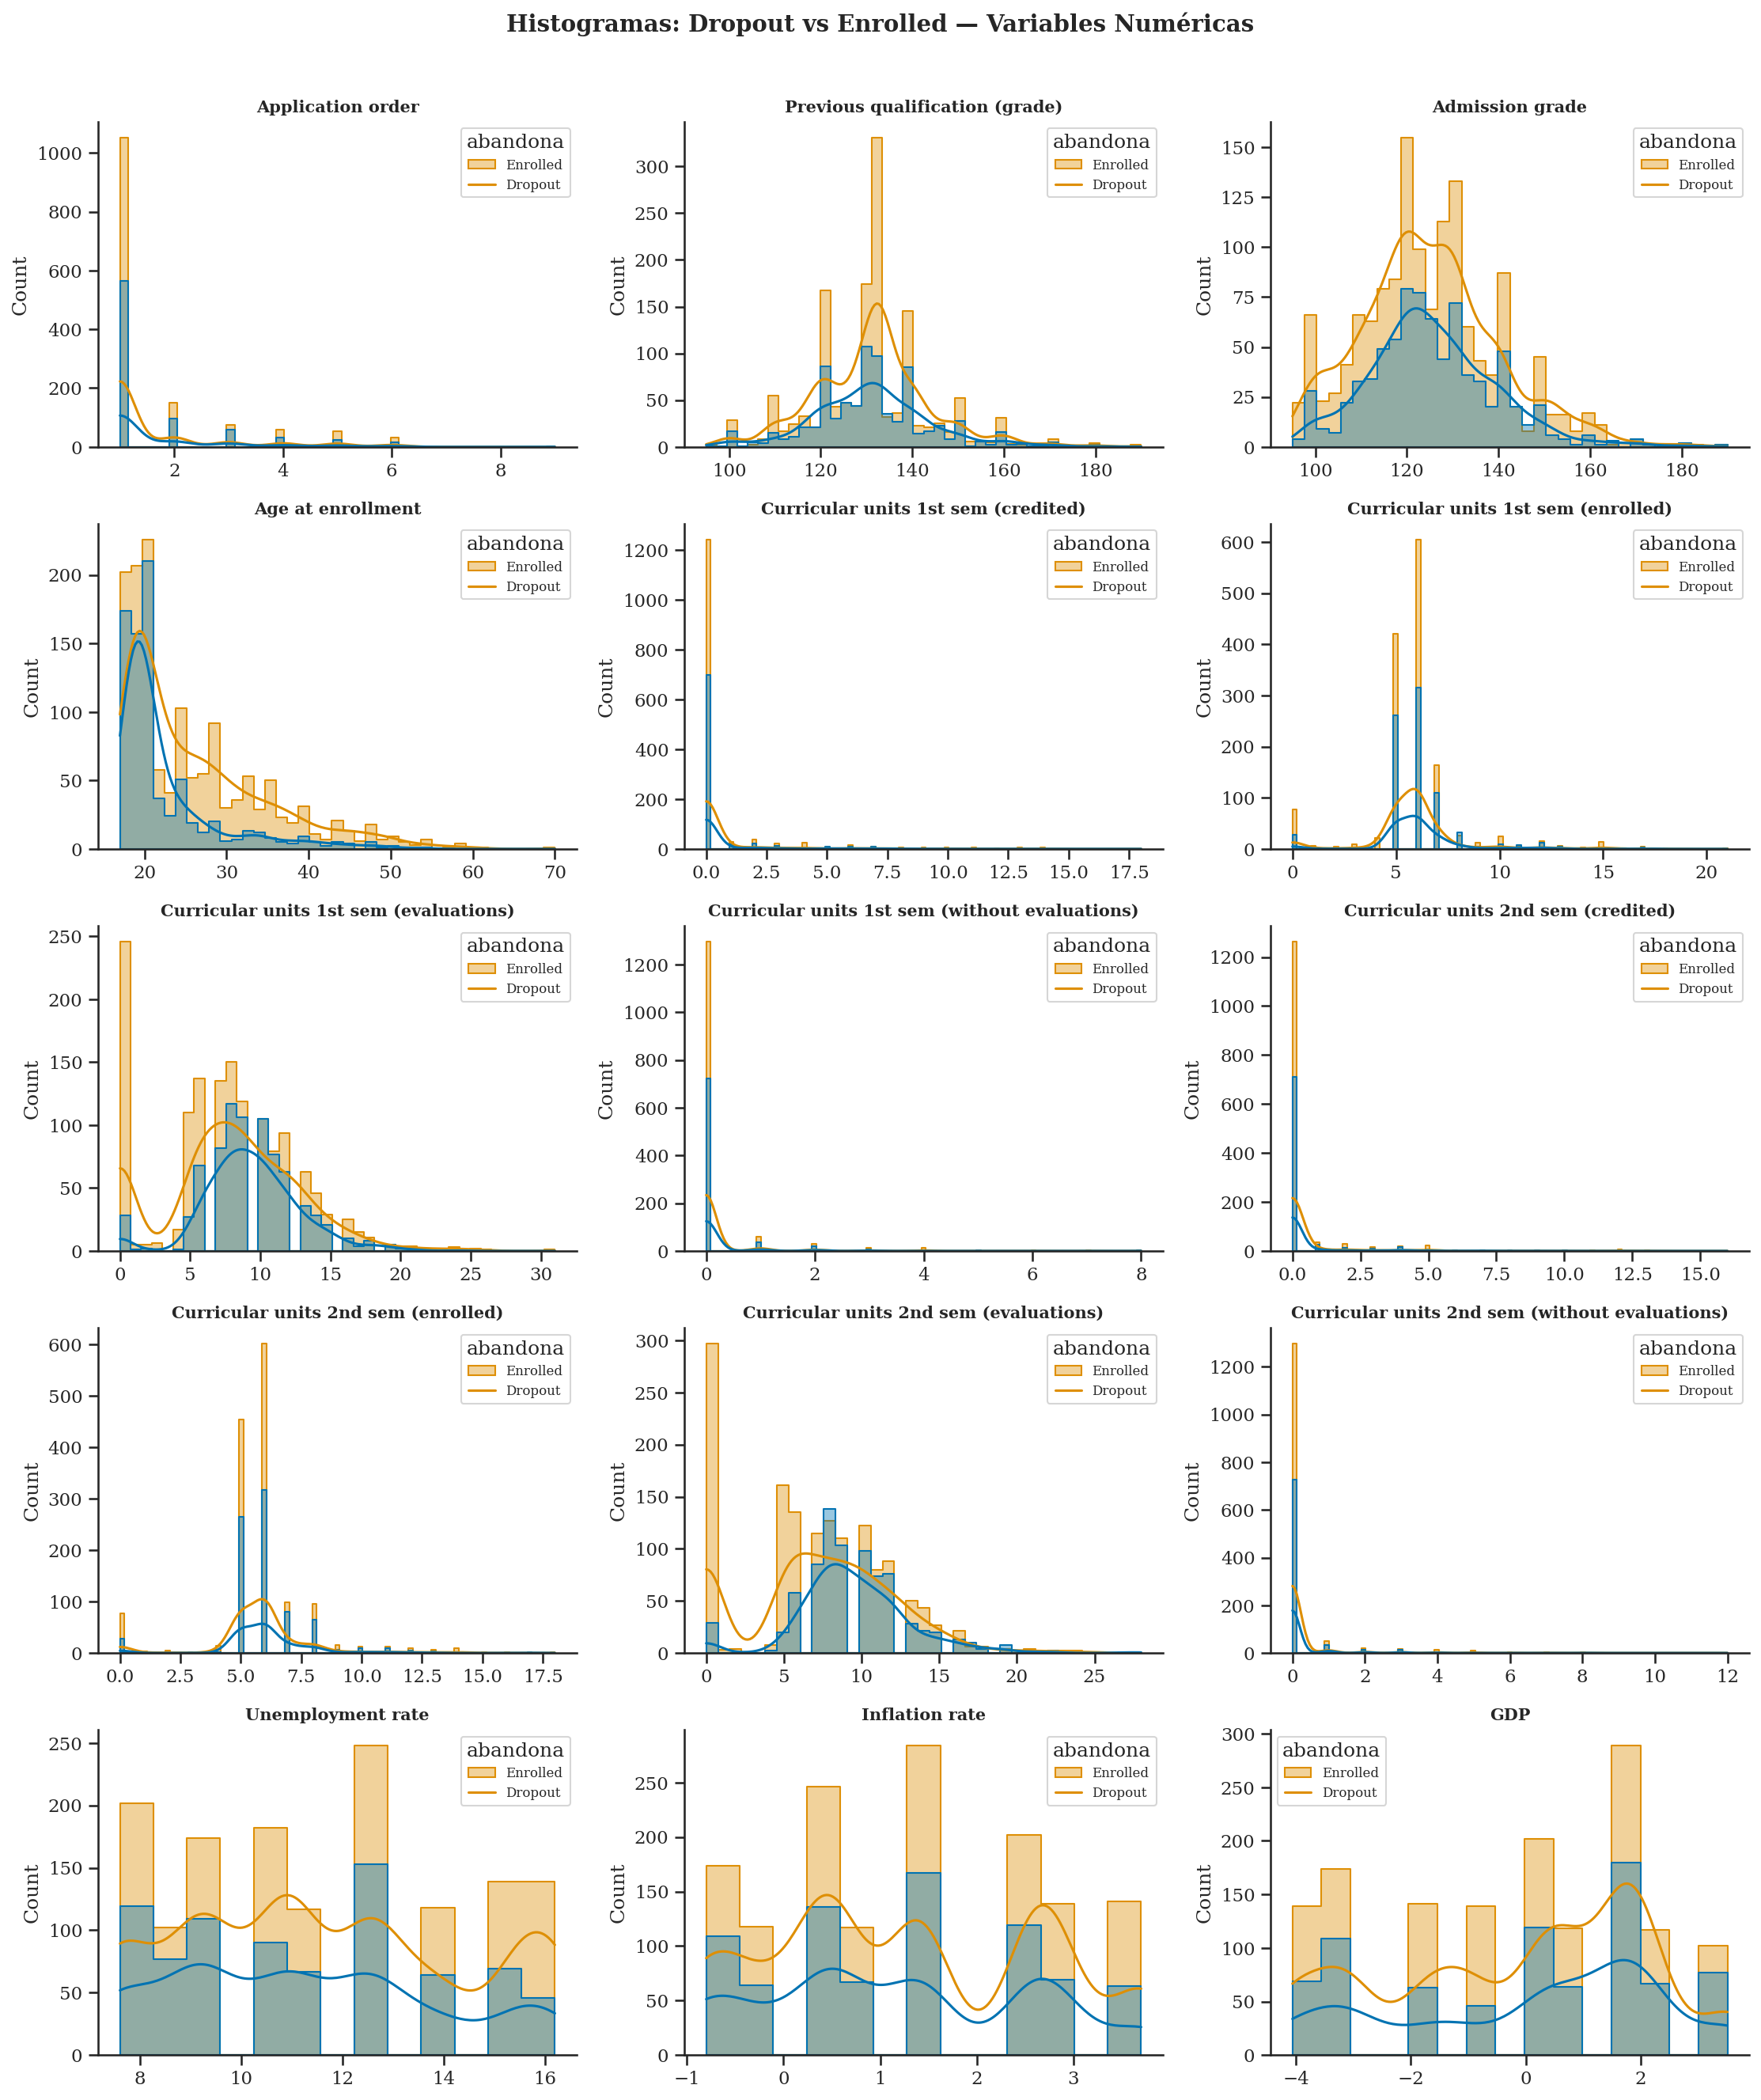

In [40]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.histplot(
        data=df, x=col, hue="abandona",
        kde=True, element="step", alpha=0.4,
        palette=PALETTE_BIN, ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].legend(title="abandona", labels=["Enrolled","Dropout"], fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogramas: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

### Boxplots por Clase

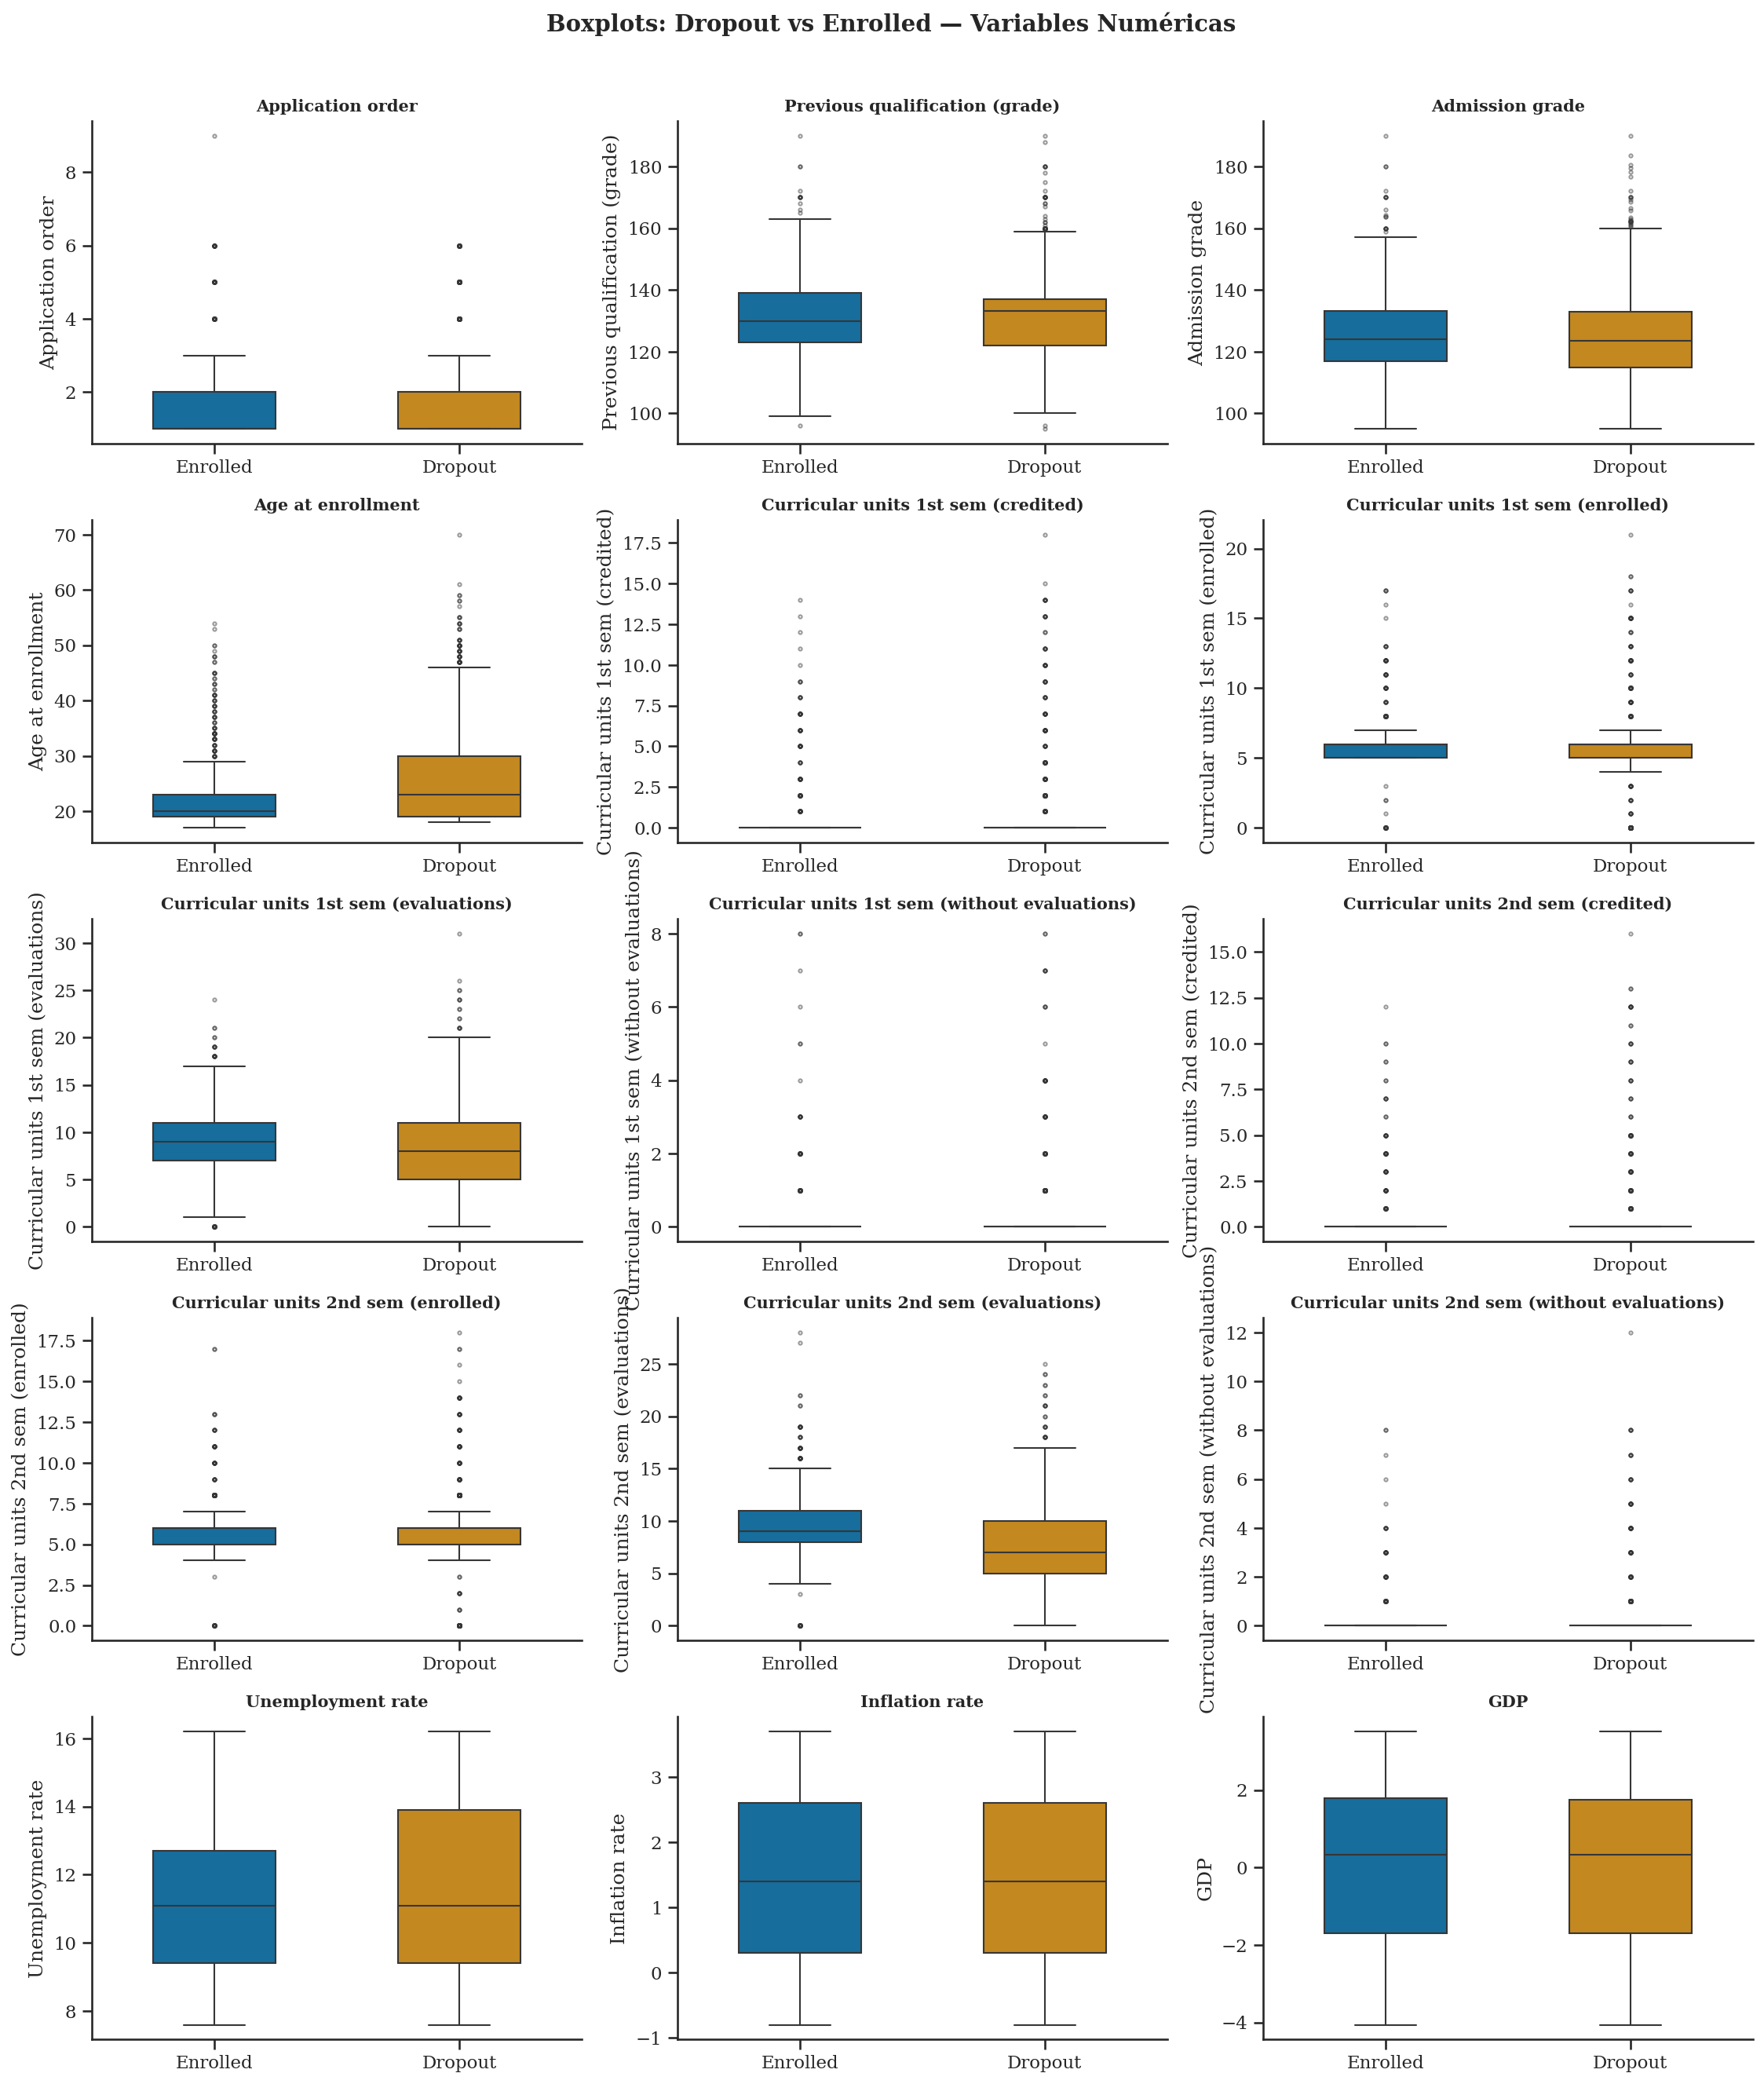

In [41]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.boxplot(
        data=df, x="abandona", y=col, hue="abandona",
        palette=PALETTE_BIN, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":2,"alpha":0.5}
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Enrolled", "Dropout"])
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

### Matriz de Correlación 

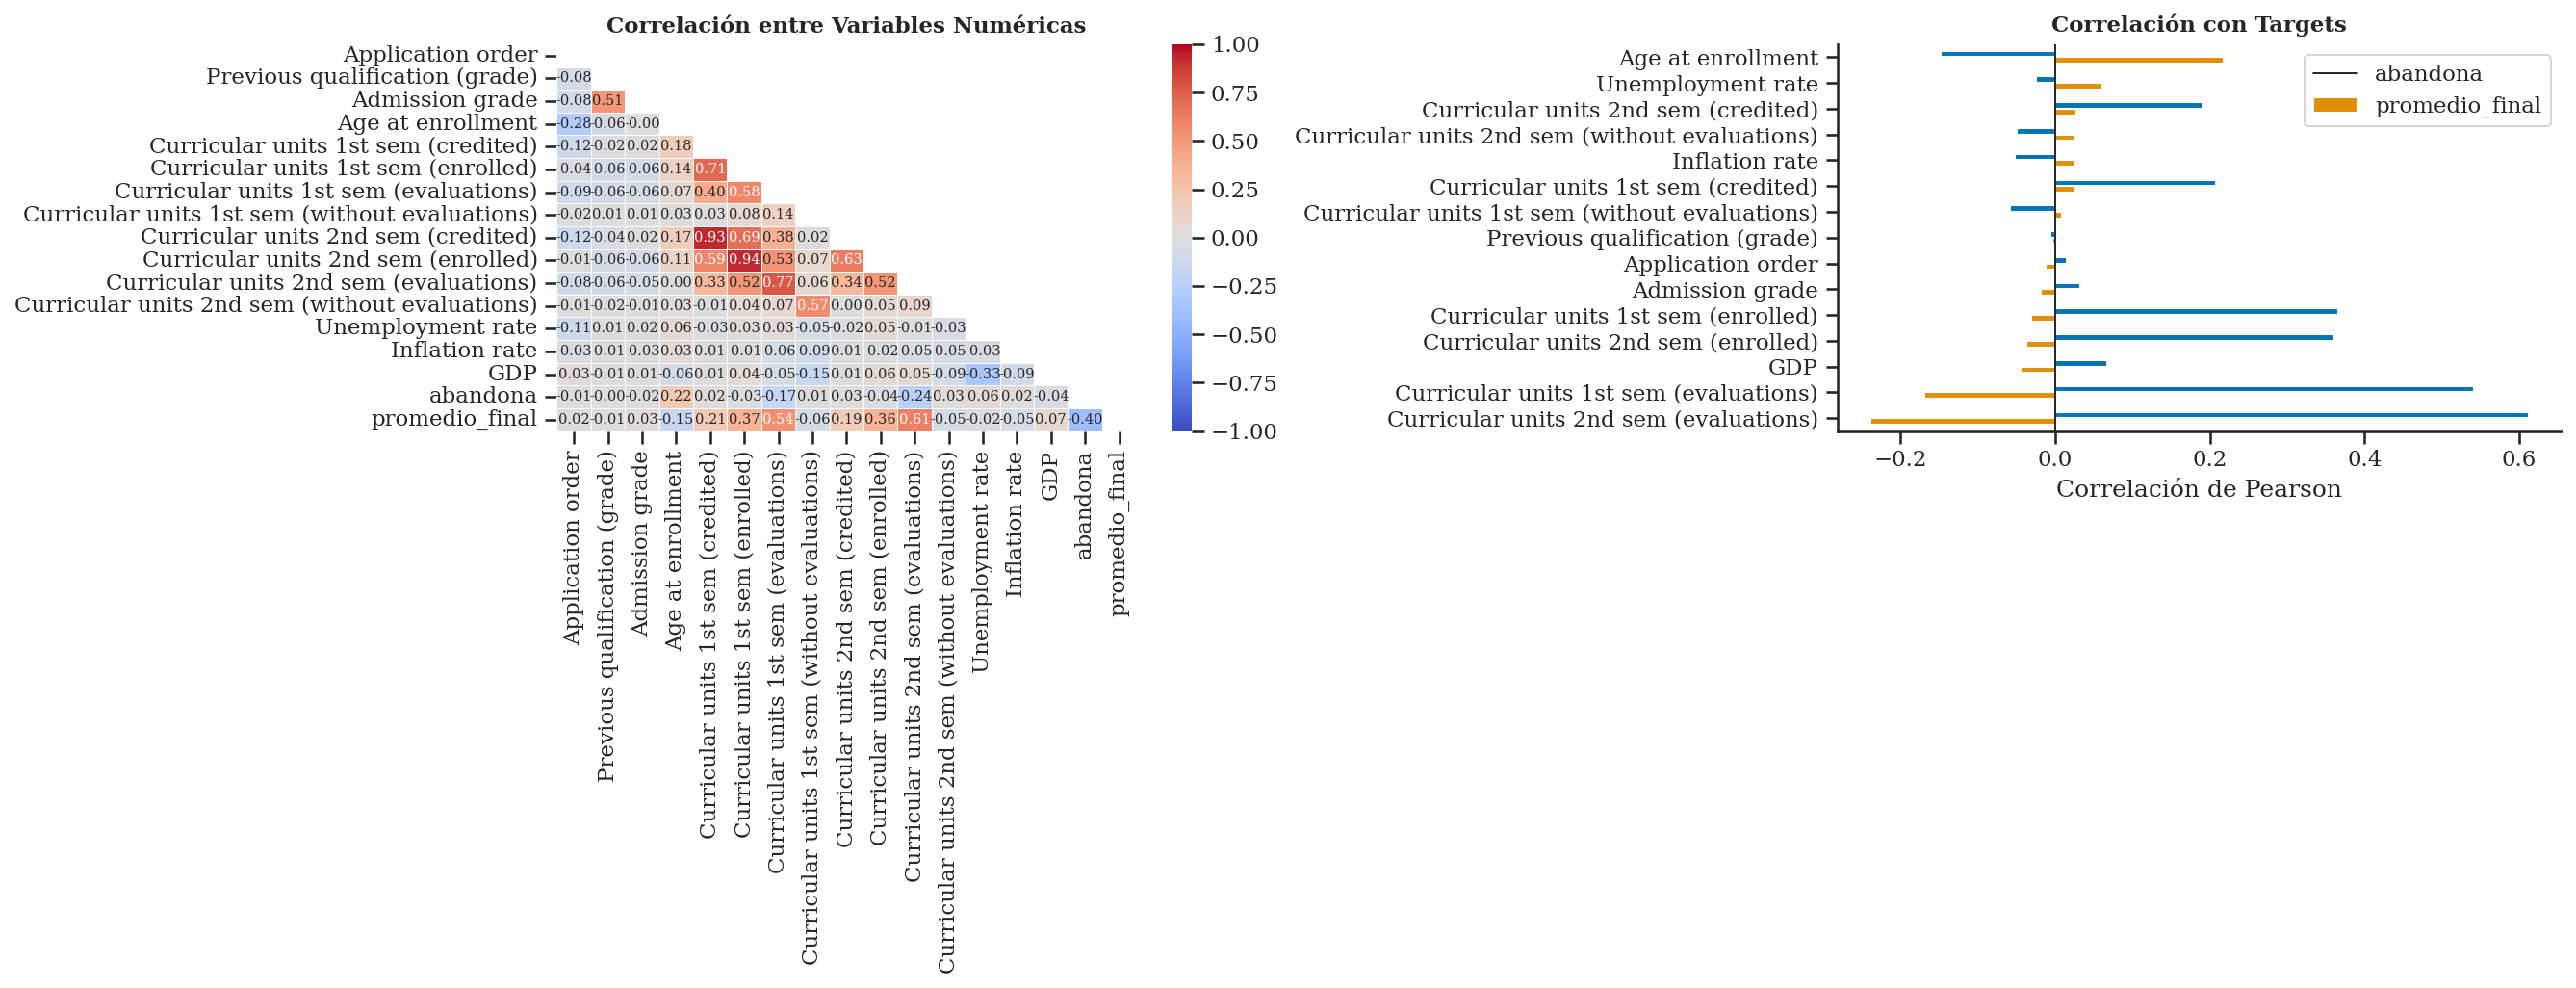

In [42]:
corr_cols = numeric_vars + ["abandona", "promedio_final"]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap=CMAP_DIV, center=0, linewidths=0.3,
    ax=axes[0], vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
axes[0].set_title("Correlación entre Variables Numéricas")

corr_targets = corr_matrix[["abandona","promedio_final"]]\
                           .drop(["abandona","promedio_final"])\
                           .sort_values("abandona")
corr_targets.plot(kind="barh", ax=axes[1],
                  color=[C_DROPOUT, C_ENROLLED], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con Targets")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].legend(["abandona","promedio_final"])

sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()

### Variables Target

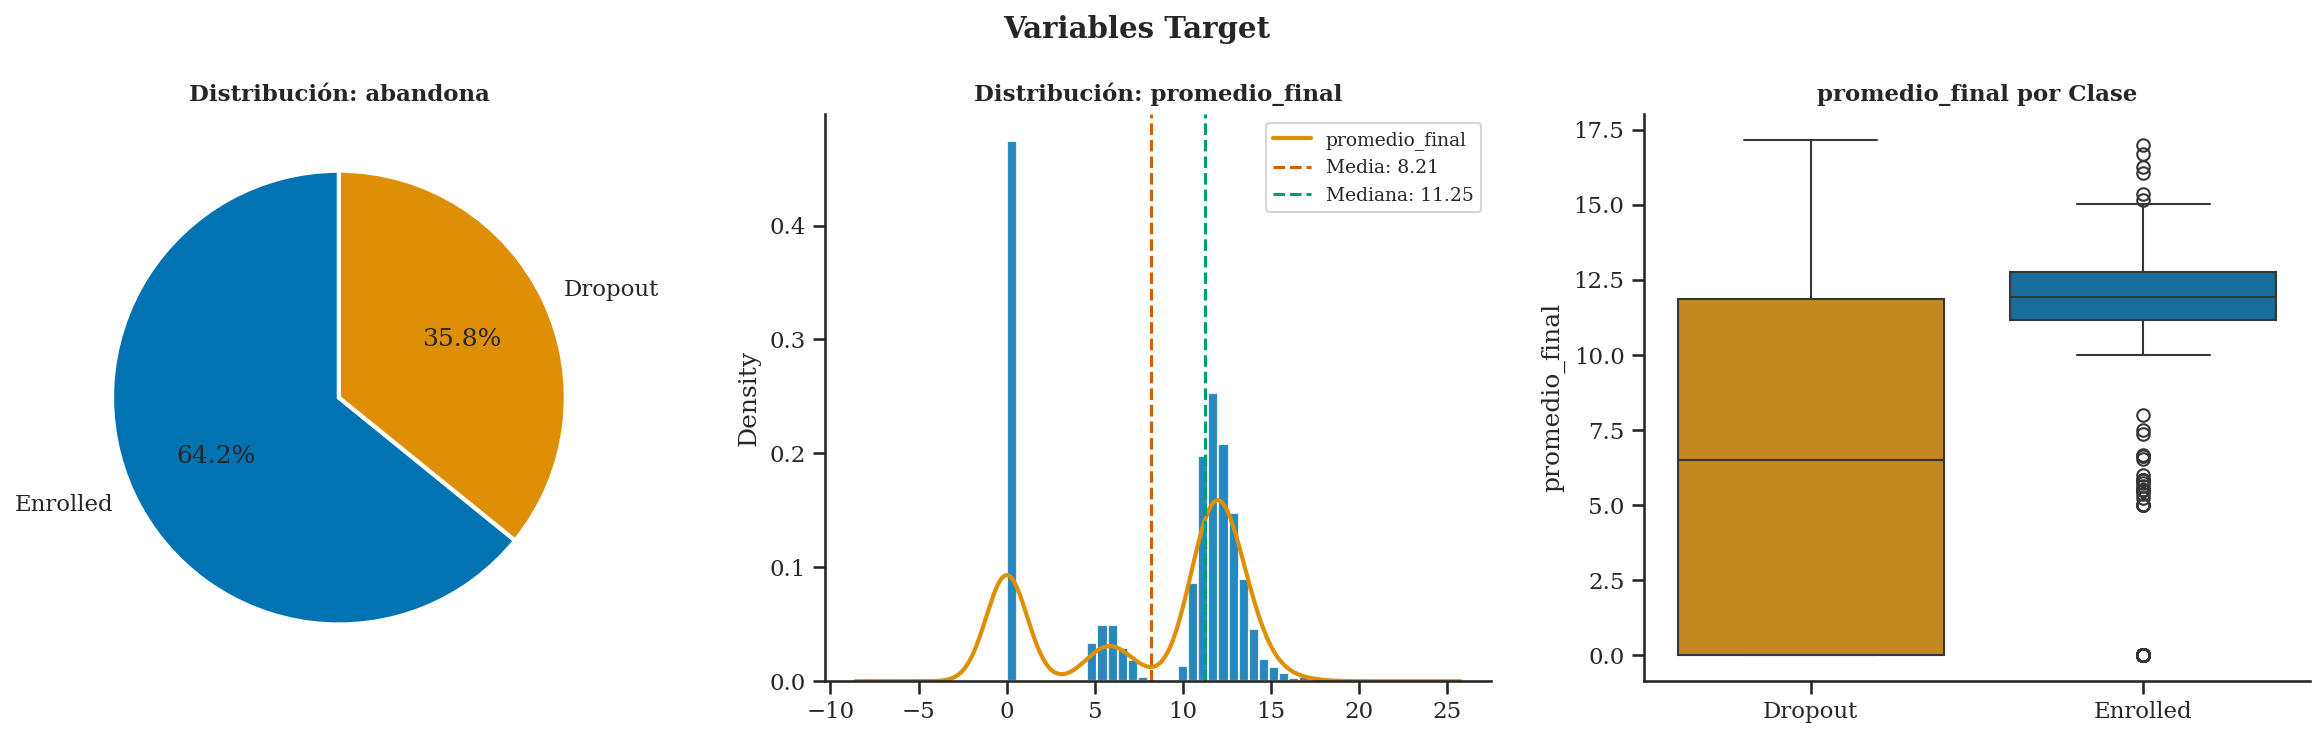


Estadísticas por clase:
           count   mean   std  min    25%    50%    75%    max
abandona                                                      
Enrolled   794.0  11.12  3.41  0.0  11.17  11.92  12.75  17.00
Dropout   1421.0   6.58  5.66  0.0   0.00   6.50  11.86  17.17


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df["abandona"].value_counts()
axes[0].pie(
    counts.values,
    labels=["Enrolled","Dropout"],
    autopct="%1.1f%%",
    colors=[C_ENROLLED, C_DROPOUT],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
axes[0].set_title("Distribución: abandona")

axes[1].hist(df["promedio_final"], bins=30,
             color=C_ENROLLED, edgecolor="white", alpha=0.85, density=True)
df["promedio_final"].plot(kind="kde", ax=axes[1], color=C_DROPOUT, linewidth=2)
axes[1].axvline(df["promedio_final"].mean(), color=C_ACCENT, linestyle="--",
                label=f'Media: {df["promedio_final"].mean():.2f}')
axes[1].axvline(df["promedio_final"].median(), color=C_GREEN, linestyle="--",
                label=f'Mediana: {df["promedio_final"].median():.2f}')
axes[1].set_title("Distribución: promedio_final")
axes[1].legend(fontsize=9)

df_box = df[["promedio_final","abandona"]].copy()
df_box["Clase"] = df_box["abandona"].map({0:"Enrolled",1:"Dropout"})
sns.boxplot(data=df_box, x="Clase", y="promedio_final", hue="Clase",
            palette={"Enrolled": C_ENROLLED, "Dropout": C_DROPOUT},
            legend=False, ax=axes[2])
axes[2].set_title("promedio_final por Clase")
axes[2].set_xlabel("")

plt.suptitle("Variables Target", fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

print("\nEstadísticas por clase:")
print(df.groupby("abandona")["promedio_final"]
        .describe().round(2)
        .rename(index={0:"Enrolled",1:"Dropout"}))

---
## Resumen del EDA

El dataset contiene **2 209 registros** (Dropout y Enrolled), **sin valores faltantes ni duplicados**, con 15 variables numéricas, 9 categóricas, 8 booleanas y 2 targets. La clase está **desbalanceada**: 64.2 % Enrolled vs 35.8 % Dropout.

**Variables categóricas:**  
Las 9 variables nominales presentan asociación significativa con `abandona` (Chi², p < 0.05). La tasa de abandono varía ampliamente entre categorías — algunas modalidades de ingreso, cursos y cualificaciones de los padres alcanzan tasas del 100 %, mientras otras están muy por debajo de la media global (0.64).

**Variables booleanas:**  
- *Tuition fees up to date* es la más discriminante: **92 %** de abandono si no está al día vs 56 % si lo está.  
- *Debtor* eleva la tasa a **78 %**; *Scholarship holder* la reduce a **51 %**.  
- *Gender* (masculino) y *Daytime/evening attendance* (nocturno) muestran tasas ligeramente superiores.  
- *Educational special needs* e *International* no muestran diferencias significativas en `promedio_final` (Mann-Whitney, p > 0.05).

**Variables numéricas:**  
- Las unidades curriculares *enrolled* y *evaluations* (ambos semestres) son las más correlacionadas con los targets (Pearson hasta 0.61 con `promedio_final`).  
- *Age at enrollment* y *Unemployment rate* se correlacionan positivamente con abandono.  
- Variables macroeconómicas (GDP, Inflation) tienen correlación débil.  
- Los histogramas revelan que muchos Dropout registran **0 unidades inscritas/evaluadas** en el 2.º semestre, señal de abandono temprano.  
- Existe **alta colinealidad** entre variables del 1.er y 2.º semestre (r hasta 0.94).

**Variable target `promedio_final`:**  
Distribución bimodal — un pico cercano a 0 (Dropout) y otro alrededor de 11–13 (Enrolled). Media = 8.21, mediana = 11.25, confirmando el sesgo izquierdo causado por los abandonos.

**Implicaciones para el modelado:** el desbalance justifica usar **F1** como métrica guía; las variables financieras (matrícula, deuda, beca) y las unidades curriculares son los predictores más prometedores.